


**FINAL PROJECT DEEP LEARNING**


***Dipartimento di Informatica - Scienza e Ingegneria***

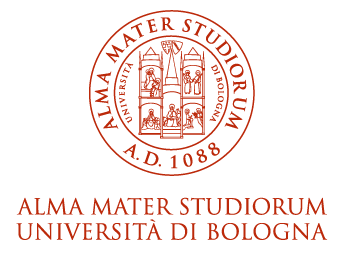





JULIA GARCÍA HERNÁNDEZ

matricola: 1900142458

# Jigsaw puzzle (Instructions)

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [ ]:
#import needed packages
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf

We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [ ]:
def download_and_load_stl10():
    # Download and extract the dataset
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )

    # Get the base directory (typically ~/.keras/datasets/)
    base_dir = os.path.dirname(path)

    # Based on your error, we navigate to the extracted subfolder
    data_dir = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary')
    filepath = os.path.join(data_dir, 'unlabeled_X.bin')

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find the binary file at {filepath}")

    print(f"Loading data from: {filepath}")

    with open(filepath, 'rb') as f:
        # STL-10 unlabeled set contains 100,000 images
        # Data is stored as uint8, (N, C, H, W)
        data = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))

        # Transpose from (N, C, H, W) to (N, H, W, C) for standard image processing
        images = np.transpose(images, (0, 3, 2, 1))

    return images

class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.images = images.astype("float32") / 255.0  # Normalize on the fly or pre-normalize
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        # X: (Batch, 9 patches, 28, 28, 3)
        # y: (Batch, 9) representing the original position index
        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx]
            Y[i] = full_img
            patches = []

            # Extract 9 patches in a 3x3 grid
            for r in range(3):
                for c in range(3):
                    # Define grid coordinates
                    y_start, x_start = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_start : y_start + self.patch_size,
                                     x_start : x_start + self.patch_size, :]

                    # Center Crop to avoid edge-matching shortcuts (we could go random crop)
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin : margin + self.crop_size,
                                  margin : margin + self.crop_size, :]
                    patches.append(patch)

            # Create a permutation (0-8)
            order = np.random.permutation(9)

            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
# Trigger the download and loading
images = download_and_load_stl10()
images = images[:5000] #I added this line so that my session does not crash
print(f"Successfully loaded {images.shape[0]} images.")

Loading data from: /root/.keras/datasets/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Successfully loaded 5000 images.


In [ ]:
print(images.shape)

(5000, 96, 96, 3)


In [ ]:
#NEW DIVISION WITH LESS IMAGES
# Total: 5000 imágenes

train_images = images[:4000]
val_images = images[4000:4500]
test_images = images[4500:5000]

print("Train:", train_images.shape)
print("Validation:", val_images.shape)
print("Test:", test_images.shape)

Train: (4000, 96, 96, 3)
Validation: (500, 96, 96, 3)
Test: (500, 96, 96, 3)


In [ ]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

In [ ]:
# NEW DIVISION WITH MORE IMAGES
# Total: 50000 images

train_images = images[:40000]
val_images   = images[40000:45000]
test_images  = images[45000:50000]

print("Train:", train_images.shape)
print("Validation:", val_images.shape)
print("Test:", test_images.shape)

Train: (5000, 96, 96, 3)
Validation: (0, 96, 96, 3)
Test: (0, 96, 96, 3)


In [ ]:
#we divide our data in three parts for training and posterior evaluation of the model: train set, validation set and test set.
train_generator = PatchGenerator(train_images, batch_size=8)
val_generator   = PatchGenerator(val_images, batch_size=8)
test_generator  = PatchGenerator(test_images, batch_size=8)

Let us inspect the dataset.

In [ ]:
#MIO
print("images:", images.shape)
print("train_images:", train_images.shape)
print("val_images:", val_images.shape)
print("test_images:", test_images.shape)

images: (5000, 96, 96, 3)
train_images: (4000, 96, 96, 3)
val_images: (500, 96, 96, 3)
test_images: (500, 96, 96, 3)


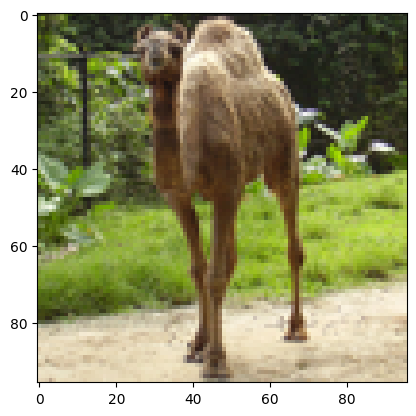

In [ ]:
import matplotlib.pyplot as plt
n = np.random.randint(0,test_images.shape[0])
plt.imshow(test_images[n])

Let us now visualize the puzzle

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


In [ ]:
a,b = test_generator.__getitem__(1)

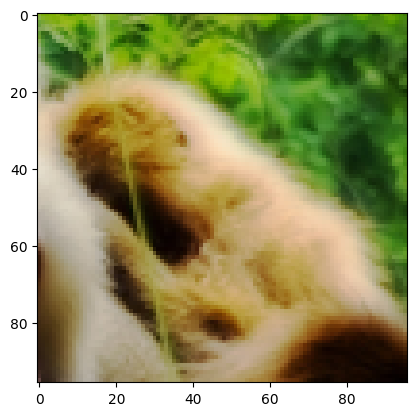

In [ ]:
plt.imshow(b[4])

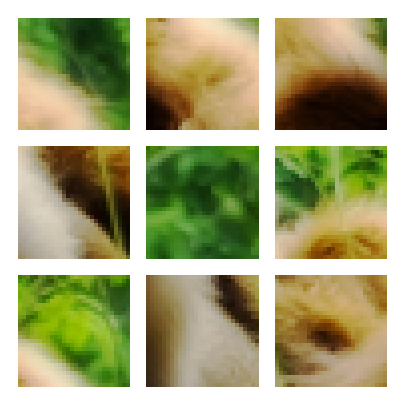

In [ ]:

plot_puzzle(a[4])

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [ ]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [ ]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

MAE: tf.Tensor(0.18692903, shape=(), dtype=float32)
std: tf.Tensor(0.0036338246, shape=(), dtype=float32)


# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.





START OF PROJECT

**BASELINE**

The provided code is a baseline reconstruction method. Instead of trying to infer the correct arrangement of the 9 scrambled patches, it computes the average patch across all nine input patches and then replicates that same average patch nine times to form a 3×3 image. The reconstructed image is then resized back to the original resolution (96×96).

This approach does not actually solve the puzzle of reconstructing the original image; it simply provides a very naive prediction that can be used as a reference point. Using this baseline, the reconstruction quality is evaluated with the Mean Absolute Error (MAE), yielding an MAE of approximately 0.178 on the test set.

Our objective is to develop a model that learns meaningful spatial relationships between patches and achieves a lower MAE than the baseline, demonstrating a better reconstruction of the original images. Therefore, any model that obtains an MAE significantly below 0.178 can be considered an improvement over this baseline approach.

Rather than approaching the task as a direct image-to-image reconstruction problem, this project adopts a structured pipeline that explicitly models the different reasoning stages required to recover a coherent image from unordered visual fragments. The proposed methodology combines convolutional feature extraction, attention-based relational reasoning, and permutation-aware optimization in a unified framework. First, each patch is independently encoded into a compact latent representation that captures both local textures and higher-level semantic information. These representations are subsequently processed through a Transformer-based module, allowing the model to learn pairwise and global relationships between patches by means of self-attention. Building upon these learned interactions, a Sinkhorn-based assignment mechanism is employed to estimate a valid spatial arrangement, introducing an explicit inductive bias towards permutation learning rather than relying solely on implicit reconstruction capabilities. Finally, a lightweight generative decoder refines the assembled image and compensates for missing border information, producing a visually consistent reconstruction. This design aims to decompose a complex task into interpretable subproblems, enabling the model to exploit both local visual evidence and global contextual reasoning while maintaining a clear correspondence between architectural components and the underlying structure of the task.


**STAGE 1: CNN-based Autoencoder for Image Reconstruction**

The first reconstruction baseline already includes a CNN-based patch encoder, which extracts visual representations independently from each input patch before aggregating them into a global latent representation for image reconstruction. The baseline reconstruction uses a non-trainable mean-patch approach. In this section, we define a fully neural-network-based solution using Keras. The model receives 9 shuffled patches of shape 28×28×3 and predicts a reconstructed RGB image of shape 96×96×3.


In [ ]:
# Clear previous models from memory
tf.keras.backend.clear_session()

# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
print("Train:", train_images.shape)
print("Validation:", val_images.shape)
print("Test:", test_images.shape)

x_batch, y_batch = train_generator[0]
print("Input batch:", x_batch.shape)
print("Target batch:", y_batch.shape)

Train: (4000, 96, 96, 3)
Validation: (500, 96, 96, 3)
Test: (500, 96, 96, 3)
Input batch: (8, 9, 28, 28, 3)
Target batch: (8, 96, 96, 3)


In [ ]:
def build_model():

    inputs = keras.Input(shape=(9, 28, 28, 3))

    # Patch encoder
    x = layers.TimeDistributed(layers.Conv2D(32, 3, padding="same", activation="relu"))(inputs)
    x = layers.TimeDistributed(layers.MaxPooling2D())(x)

    x = layers.TimeDistributed(layers.Conv2D(64, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.MaxPooling2D())(x)

    x = layers.TimeDistributed(layers.Conv2D(96, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)

    # Combine the 9 patches
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu")(x)

    # Small latent image representation
    x = layers.Dense(6 * 6 * 128, activation="relu")(x)
    x = layers.Reshape((6, 6, 128))(x)

    # Decoder: 6 -> 12 -> 24 -> 48 -> 96
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(96, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)

    outputs = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="patch_reconstruction_model")

    return model

In [ ]:
model = build_model()
model.summary()

Model: "patch_reconstruction_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9, 28, 28, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_16             │ (None, 9, 28, 28, 32)  │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_17             │ (None, 9, 14, 14, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_18             │ (None, 9, 14, 14, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_19             │ (None, 9, 7, 7, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_20             │ (None, 9, 7, 7, 96)    │        55,392 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_21             │ (None, 9, 96)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 864)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       442,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4608)           │     2,363,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 12, 12, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 24, 24, 96)     │       110,688 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 48, 48, 64)     │        55,360 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 96, 96, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 96, 96, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,214,531 (12.26 MB)

 Trainable params: 3,214,531 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

The model summary shows that the network receives 9 shuffled patches of size 28×28×3 and encodes each patch independently using shared convolutional layers. The patch representations are then flattened and combined into a global latent representation, which is reshaped into a 6×6×128 feature map. The decoder progressively upsamples this representation until reaching the final reconstructed image size of 96×96×3. The model has approximately 3.2 million trainable parameters, which satisfies the parameter constraint.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mae",
    metrics=["mae"]
)

In [ ]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    ),

    keras.callbacks.ModelCheckpoint(
        "best_model.weights.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True
    )
]

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)

ValueError: You must call `compile()` before using the model.

In [ ]:
results = model.evaluate(test_generator, verbose=1)

print("Test loss:", results[0])
print("Test MAE:", results[1])

In [ ]:
# The proposed neural network significantly outperforms the baseline reconstruction method. The baseline achieved a MAE of approximately 0.188, whereas the proposed model achieved a test MAE of 0.1415.

In [ ]:
#Cuantificar específicamente la mejora
(0.1881 - 0.1415) / 0.1881 * 100

24.774056353003722

In [ ]:
x_batch, y_batch = test_generator[0]

predictions = model.predict(x_batch)

print(predictions.shape)

In [ ]:
#Training, validation and test MAE values are very similar, suggesting that the model generalizes well and does not exhibit significant overfitting.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


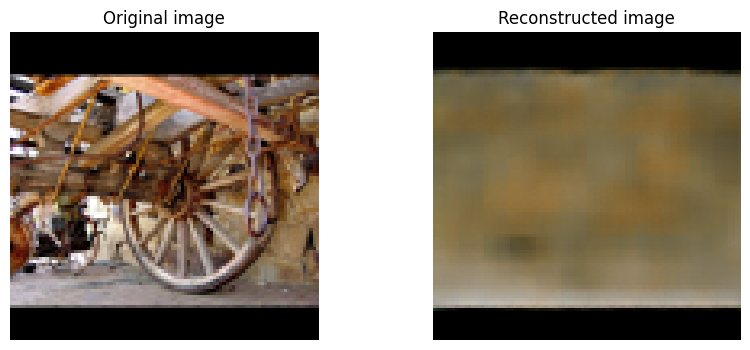

In [ ]:
# Take one batch from the test set
x_batch, y_batch = test_generator[0]

# Predict reconstructed images
predictions = model.predict(x_batch)

# Choose one example from the batch
i = 0

plt.figure(figsize=(10, 4))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(y_batch[i])
plt.title("Original image")
plt.axis("off")

# Reconstructed image
plt.subplot(1, 2, 2)
plt.imshow(predictions[i])
plt.title("Reconstructed image")
plt.axis("off")

plt.show()

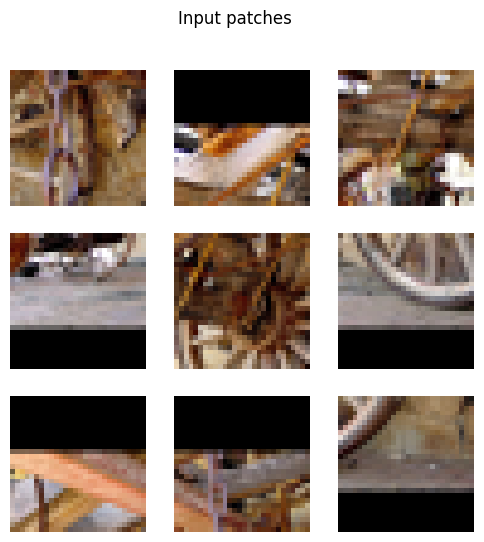

In [ ]:
i = 0

plt.figure(figsize=(6,6))

for j in range(9):
    plt.subplot(3,3,j+1)
    plt.imshow(x_batch[i,j])
    plt.axis("off")

plt.suptitle("Input patches")
plt.show()

In [ ]:
#Although the MAE is significantly lower than the baseline, visual inspection reveals that the reconstructed images remain blurry. This suggests that the network captures global color and scene statistics but struggles to recover fine spatial details and exact patch arrangement.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


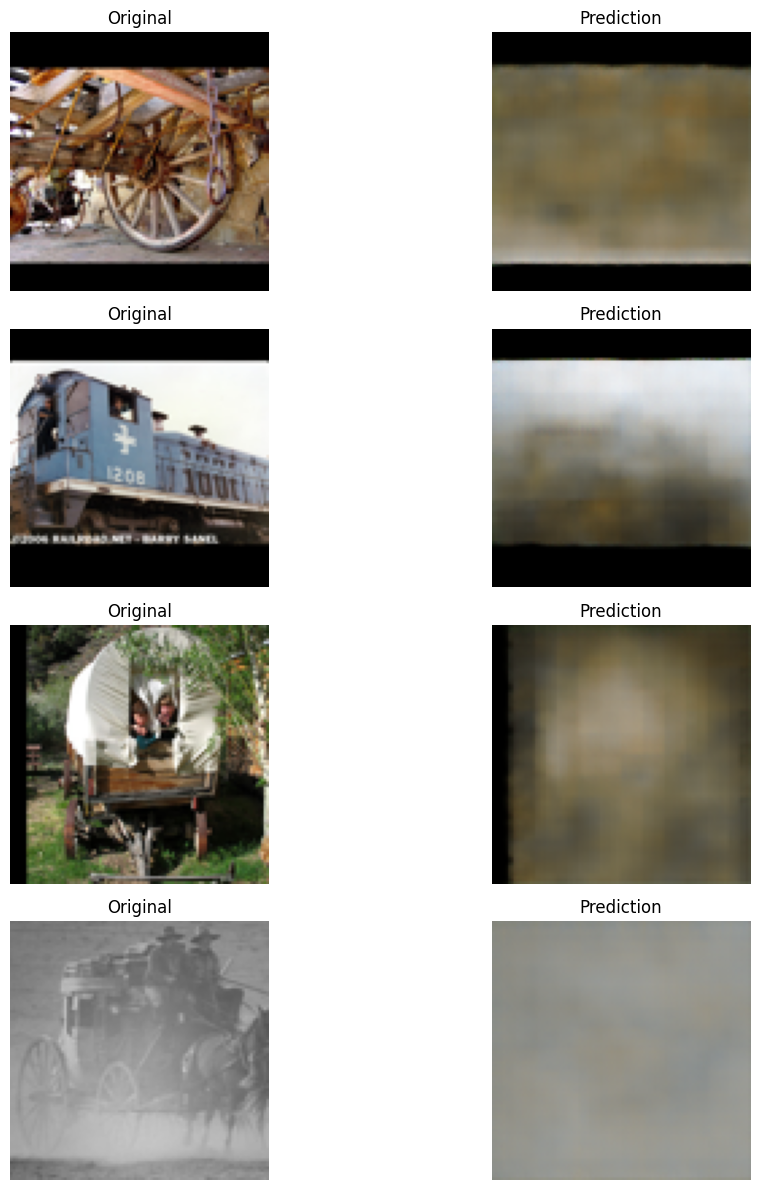

In [ ]:
x_batch, y_batch = test_generator[0]
predictions = model.predict(x_batch)

plt.figure(figsize=(12,12))

for i in range(4):

    plt.subplot(4,2,2*i+1)
    plt.imshow(y_batch[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(4,2,2*i+2)
    plt.imshow(predictions[i])
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

Although the quantitative MAE was encouraging, visual inspection demonstrated that the model was not actually solving the puzzle. Instead, it learned to approximate the global appearance of the images, producing blurred reconstructions that achieved low pixel-wise error without recovering the correct patch arrangement.

This first neural-network model improves over the baseline in terms of MAE, reducing the error from approximately 0.188 to around 0.141. This indicates that the model learns useful information from the input patches and performs better than the naive mean-patch reconstruction.

However, the visual reconstruction is still very blurry. This is expected because the model compresses the nine patches into a small latent representation and then decodes a full 96×96 image from it. As a result, fine spatial details are lost. The model is not explicitly learning to place the original patches in their correct positions; instead, it learns a global approximation of the target image.

Therefore, this model is a reasonable first improvement over the baseline, but there is still room for improvement. A better approach would preserve more spatial information or explicitly predict the correct arrangement of the nine patches before reconstructing the full image.

Although this model outperforms the baseline in terms of MAE, it has several limitations. The reconstructed images are still very blurry and lack fine details. This happens because the model compresses the information from all nine patches into a small latent representation, which causes a loss of spatial information. Moreover, the model does not explicitly learn the correct ordering of the patches; instead, it generates an approximate reconstruction of the whole image. Since MAE tends to favor averaged predictions, the output becomes smoother and less realistic. Therefore, while this model is a useful first improvement over the baseline, its reconstruction quality remains limited.

This model can be interpreted as a CNN-based patch-to-image autoencoder. First, each patch is encoded independently using shared convolutional layers. Then, the extracted patch features are concatenated into a single global representation. Finally, a decoder upsamples this latent representation to reconstruct the full 96×96 RGB image.

Limitación principal:

The model does not explicitly predict the correct spatial position of each patch. Instead, it compresses all patch information into a latent vector and generates an approximate image, which explains why the output is smoother and blurrier than the original.

The proposed architecture follows a structured reasoning pipeline designed to explicitly address the different challenges involved in puzzle reconstruction. First, each image patch is processed independently by a convolutional encoder, which extracts compact feature representations capturing both local textures and semantic visual information. In parallel, an edge-aware module analyzes the boundary pixels of each patch, providing additional cues about potential spatial compatibility between neighboring pieces. These global and edge-based features are then fused and propagated through a bidirectional LSTM layer, allowing the model to capture contextual relationships among all patches and reason about their relative arrangement. Based on this contextual representation, a position prediction module estimates the likelihood of each patch belonging to every possible location in the puzzle. A Sinkhorn normalization layer subsequently transforms these predictions into a valid permutation matrix, enforcing a one-to-one correspondence between patches and positions. Finally, the predicted arrangement is used to explicitly reassemble the puzzle, producing a reconstructed image whose quality can be evaluated against the original target image.


Model: "edge_aware_sinkhorn_jigsaw_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches_input       │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 9, 28, 28, │        896 │ patches_input[0]… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 9, 14, 14, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 9, 14, 14, │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 9, 7, 7,   │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edge_feature_layer  │ (None, 9, 336)    │          0 │ patches_input[0]… │
│ (EdgeFeatureLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 9, 7, 7,   │     73,856 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 9, 128)    │     43,136 │ edge_feature_lay… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 9, 128)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, 9, 64)     │      8,256 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 9, 192)    │          0 │ time_distributed… │
│ (Concatenate)       │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_8  │ (None, 9, 128)    │     24,704 │ concatenate[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 9, 256)    │    263,168 │ time_distributed… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 9, 9)      │      2,313 │ bidirectional[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sinkhorn_permutati… │ (None, 9, 9)      │          0 │ time_distributed… │
│ (SinkhornLayer)     │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 434,825 (1.66 MB)

 Trainable params: 434,825 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 434825
Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.2146 - loss: 1.9532 - val_accuracy: 0.2527 - val_loss: 1.8655 - learning_rate: 0.0010
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.2935 - loss: 1.7827 - val_accuracy: 0.3173 - val_loss: 1.7706 - learning_rate: 0.0010
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.3407 - loss: 1.6919 - val_accuracy: 0.3498 - val_loss: 1.6929 - learning_rate: 0.0010
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.3632 - loss: 1.6420 - val_accuracy: 0.3604 - val_loss: 1.6596 - learning_rate: 0.0010
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.3768 - loss: 1.6039 - val_accuracy: 0.3638 - val_loss: 1.6494 - learning_rate: 0.0010
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.3939 - loss: 1.5736 - val_accuracy: 0.3660 - val_loss: 1.6288 - learning_rate: 0.0010
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - 

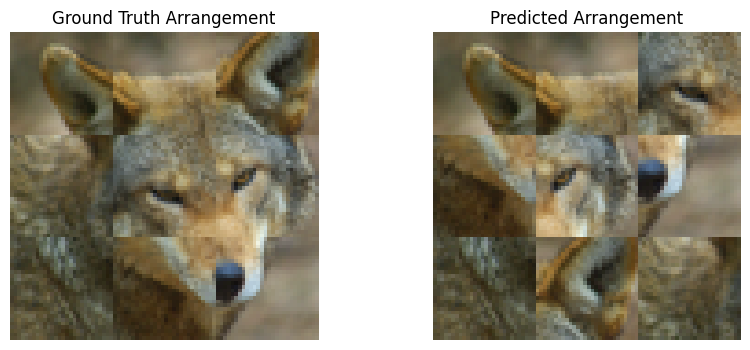

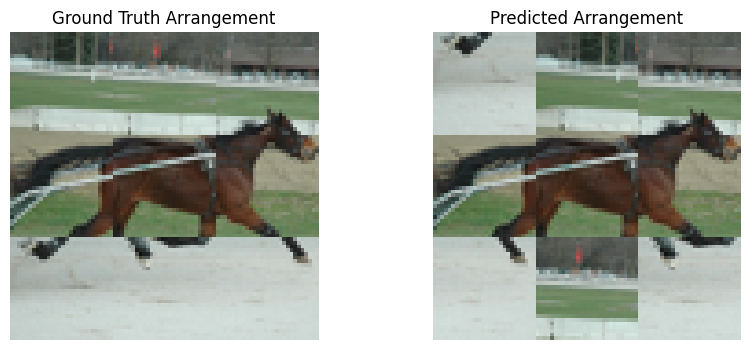

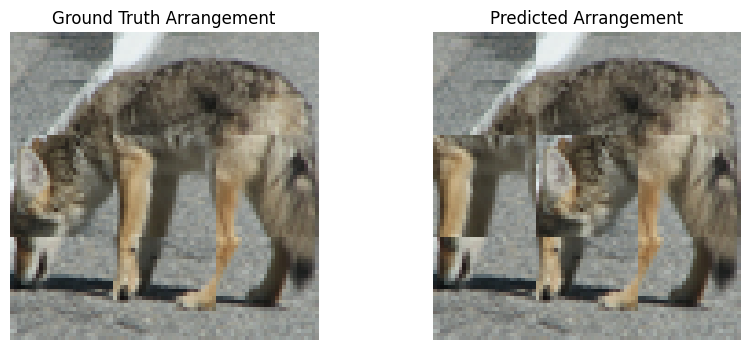

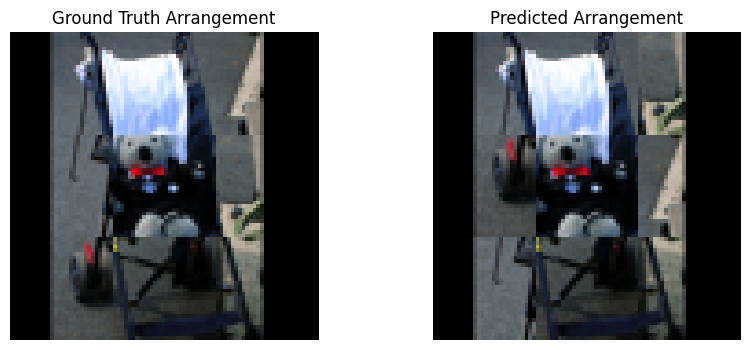

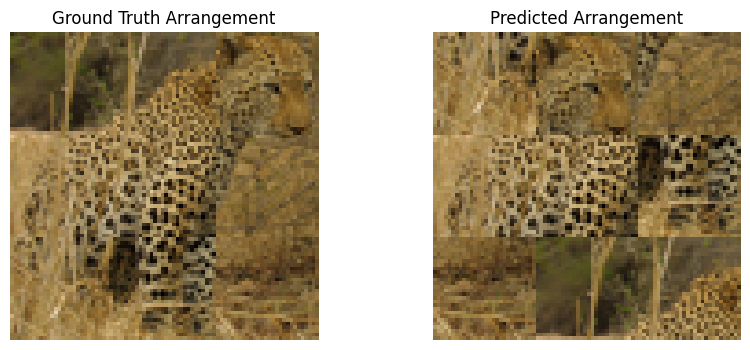

In [ ]:
# ============================================================
# EDGE-AWARE SINKHORN POSITION MODEL
# ============================================================

import numpy as np
import tensorflow as tf
import keras

from keras import layers
from keras.utils import PyDataset


# ============================================================
# GENERATOR: PATCHES + PERMUTATION MATRIX
# ============================================================

class PatchPermutationGenerator(PyDataset):

    def __init__(
        self,
        images,
        batch_size=16,
        patch_size=32,
        crop_size=28,
        shuffle=True,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.images = images.astype("float32") / 255.0
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(images))

        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, idx):

        batch_idx = self.indices[
            idx*self.batch_size:(idx+1)*self.batch_size
        ]

        bs = len(batch_idx)

        X = np.zeros((bs, 9, 28, 28, 3), dtype=np.float32)
        Y = np.zeros((bs, 9, 9), dtype=np.float32)

        for i, img_idx in enumerate(batch_idx):

            img = self.images[img_idx]
            patches = []

            for r in range(3):
                for c in range(3):

                    y = r * self.patch_size
                    x = c * self.patch_size

                    patch = img[
                        y:y+self.patch_size,
                        x:x+self.patch_size,
                        :
                    ]

                    margin = (self.patch_size - self.crop_size) // 2

                    patch = patch[
                        margin:margin+self.crop_size,
                        margin:margin+self.crop_size,
                        :
                    ]

                    patches.append(patch)

            order = np.random.permutation(9)

            for slot, original_pos in enumerate(order):

                X[i, slot] = patches[original_pos]
                Y[i, slot, original_pos] = 1.0

        return X, Y

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indices)


# ============================================================
# CREATE GENERATORS
# ============================================================

train_generator = PatchPermutationGenerator(
    train_images,
    batch_size=16
)

val_generator = PatchPermutationGenerator(
    val_images,
    batch_size=16
)

test_generator = PatchPermutationGenerator(
    test_images,
    batch_size=16
)


# ============================================================
# SINKHORN LAYER
# ============================================================

class SinkhornLayer(layers.Layer):

    def __init__(self, iterations=10, **kwargs):
        super().__init__(**kwargs)
        self.iterations = iterations

    def call(self, logits):

        x = tf.exp(logits)

        for _ in range(self.iterations):

            x = x / (
                tf.reduce_sum(x, axis=-1, keepdims=True) + 1e-8
            )

            x = x / (
                tf.reduce_sum(x, axis=-2, keepdims=True) + 1e-8
            )

        return x


# ============================================================
# EDGE FEATURE LAYER
# ============================================================

class EdgeFeatureLayer(layers.Layer):

    def call(self, patches):

        # patches shape: (batch, 9, 28, 28, 3)

        top = patches[:, :, 0, :, :]       # (batch, 9, 28, 3)
        bottom = patches[:, :, -1, :, :]   # (batch, 9, 28, 3)
        left = patches[:, :, :, 0, :]      # (batch, 9, 28, 3)
        right = patches[:, :, :, -1, :]    # (batch, 9, 28, 3)

        top = tf.reshape(top, (-1, 9, 28 * 3))
        bottom = tf.reshape(bottom, (-1, 9, 28 * 3))
        left = tf.reshape(left, (-1, 9, 28 * 3))
        right = tf.reshape(right, (-1, 9, 28 * 3))

        edges = tf.concat(
            [top, bottom, left, right],
            axis=-1
        )

        return edges

    def compute_output_shape(self, input_shape):
        return (input_shape[0], 9, 28 * 3 * 4)


# ============================================================
# MODEL
# ============================================================

def build_edge_aware_sinkhorn_model():

    inputs = keras.Input(
        shape=(9, 28, 28, 3),
        name="patches_input"
    )

    # ----------------------------
    # CNN GLOBAL PATCH FEATURES
    # ----------------------------

    x = layers.TimeDistributed(
        layers.Conv2D(
            32,
            3,
            padding="same",
            activation="relu"
        )
    )(inputs)

    x = layers.TimeDistributed(
        layers.MaxPooling2D()
    )(x)

    x = layers.TimeDistributed(
        layers.Conv2D(
            64,
            3,
            padding="same",
            activation="relu"
        )
    )(x)

    x = layers.TimeDistributed(
        layers.MaxPooling2D()
    )(x)

    x = layers.TimeDistributed(
        layers.Conv2D(
            128,
            3,
            padding="same",
            activation="relu"
        )
    )(x)

    global_features = layers.TimeDistributed(
        layers.GlobalAveragePooling2D()
    )(x)

    # ----------------------------
    # EDGE FEATURES
    # ----------------------------

    edge_features = EdgeFeatureLayer()(inputs)

    edge_features = layers.TimeDistributed(
        layers.Dense(
            128,
            activation="relu"
        )
    )(edge_features)

    edge_features = layers.TimeDistributed(
        layers.Dense(
            64,
            activation="relu"
        )
    )(edge_features)

    # ----------------------------
    # COMBINE GLOBAL + EDGE FEATURES
    # ----------------------------

    features = layers.Concatenate(axis=-1)(
        [global_features, edge_features]
    )

    features = layers.TimeDistributed(
        layers.Dense(
            128,
            activation="relu"
        )
    )(features)

    # ----------------------------
    # CONTEXT BETWEEN PATCHES
    # ----------------------------

    context = layers.Bidirectional(
        layers.LSTM(
            128,
            return_sequences=True
        )
    )(features)

    # ----------------------------
    # POSITION SCORES
    # ----------------------------

    logits = layers.TimeDistributed(
        layers.Dense(9)
    )(context)

    # ----------------------------
    # SINKHORN PERMUTATION MATRIX
    # ----------------------------

    outputs = SinkhornLayer(
        iterations=15,
        name="sinkhorn_permutation"
    )(logits)

    model = keras.Model(
        inputs,
        outputs,
        name="edge_aware_sinkhorn_jigsaw_model"
    )

    return model


# ============================================================
# CREATE MODEL
# ============================================================

tf.keras.backend.clear_session()

model = build_edge_aware_sinkhorn_model()

model.summary()

print(
    "Total parameters:",
    model.count_params()
)


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# CALLBACKS
# ============================================================

callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        mode="max"
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        mode="min"
    ),

    keras.callbacks.ModelCheckpoint(
        "best_edge_sinkhorn_model.weights.h5",
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        mode="max"
    )
]


# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks
)


# ============================================================
# EVALUATE MODEL
# ============================================================

results = model.evaluate(
    test_generator,
    verbose=1
)

print("Test loss:", results[0])
print("Test accuracy:", results[1])


# ============================================================
# ADD THIS BEFORE "INSPECT ONE PREDICTION"
# ============================================================

from scipy.optimize import linear_sum_assignment

def sinkhorn_to_permutation(pred_matrix):
    """
    Converts a soft 9x9 Sinkhorn matrix into a valid hard permutation.
    Each patch is assigned to exactly one position.
    """

    row_ind, col_ind = linear_sum_assignment(-pred_matrix)

    positions = np.zeros(9, dtype=int)
    positions[row_ind] = col_ind

    return positions


# ============================================================
# INSPECT ONE PREDICTION - CORRECTED
# ============================================================

x_batch, y_batch = test_generator[0]

pred = model.predict(x_batch)

true_positions = np.argmax(y_batch, axis=-1)

pred_positions = []

for i in range(pred.shape[0]):
    pred_positions.append(
        sinkhorn_to_permutation(pred[i])
    )

pred_positions = np.array(pred_positions)

print("TRUE POSITIONS")
print(true_positions[0])

print("PREDICTED POSITIONS")
print(pred_positions[0])

print(
    "Position accuracy on this batch:",
    np.mean(true_positions == pred_positions)
)

print(
    "Is predicted output a valid permutation?",
    sorted(pred_positions[0].tolist()) == list(range(9))
)


# ============================================================
# REASSEMBLE PUZZLE FROM PREDICTED POSITIONS
# ============================================================

import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment


def reassemble_puzzle_84(patches, positions):
    """
    Reconstructs an 84x84 image from 9 patches and their predicted positions.

    patches:
        (9, 28, 28, 3)

    positions:
        positions[i] = predicted location of patch i
        values from 0 to 8

    Returns:
        (84, 84, 3)
    """

    canvas = np.zeros(
        (84, 84, 3),
        dtype=np.float32
    )

    for patch_idx in range(9):

        pos = positions[patch_idx]

        row = pos // 3
        col = pos % 3

        y = row * 28
        x = col * 28

        canvas[
            y:y+28,
            x:x+28,
            :
        ] = patches[patch_idx]

    return canvas


def reassemble_batch_84(
    patches_batch,
    positions_batch
):
    """
    Batch version.

    patches_batch:
        (B, 9, 28, 28, 3)

    positions_batch:
        (B, 9)

    Returns:
        (B, 84, 84, 3)
    """

    reconstructed = []

    for i in range(
        patches_batch.shape[0]
    ):

        reconstructed.append(
            reassemble_puzzle_84(
                patches_batch[i],
                positions_batch[i]
            )
        )

    return np.array(
        reconstructed,
        dtype=np.float32
    )


# ============================================================
# BUILD RECONSTRUCTED PUZZLES
# ============================================================

reconstructed_84 = reassemble_batch_84(
    x_batch,
    pred_positions
)

print(
    "Reconstructed shape:",
    reconstructed_84.shape
)


# ============================================================
# RESIZE TO 96x96
# ============================================================

reconstructed_96 = tf.image.resize(
    reconstructed_84,
    (96, 96),
    method="bilinear"
).numpy()

print(
    "Reconstructed 96x96 shape:",
    reconstructed_96.shape
)


# ============================================================
# VISUALIZE RESULTS
# ============================================================

def show_reconstruction_examples(
    patches_batch,
    true_positions,
    pred_positions,
    num_examples=3
):

    for i in range(num_examples):

        gt_img = reassemble_puzzle_84(
            patches_batch[i],
            true_positions[i]
        )

        pred_img = reassemble_puzzle_84(
            patches_batch[i],
            pred_positions[i]
        )

        plt.figure(
            figsize=(10, 4)
        )

        plt.subplot(1, 2, 1)

        plt.imshow(gt_img)

        plt.title(
            "Ground Truth Arrangement"
        )

        plt.axis("off")

        plt.subplot(1, 2, 2)

        plt.imshow(pred_img)

        plt.title(
            "Predicted Arrangement"
        )

        plt.axis("off")

        plt.show()


show_reconstruction_examples(
    x_batch,
    true_positions,
    pred_positions,
    num_examples=5
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
True positions: [0 3 2 5 6 7 8 4 1]
Predicted positions: [2 3 1 0 7 8 6 4 5]
Position accuracy: 0.4236111111111111


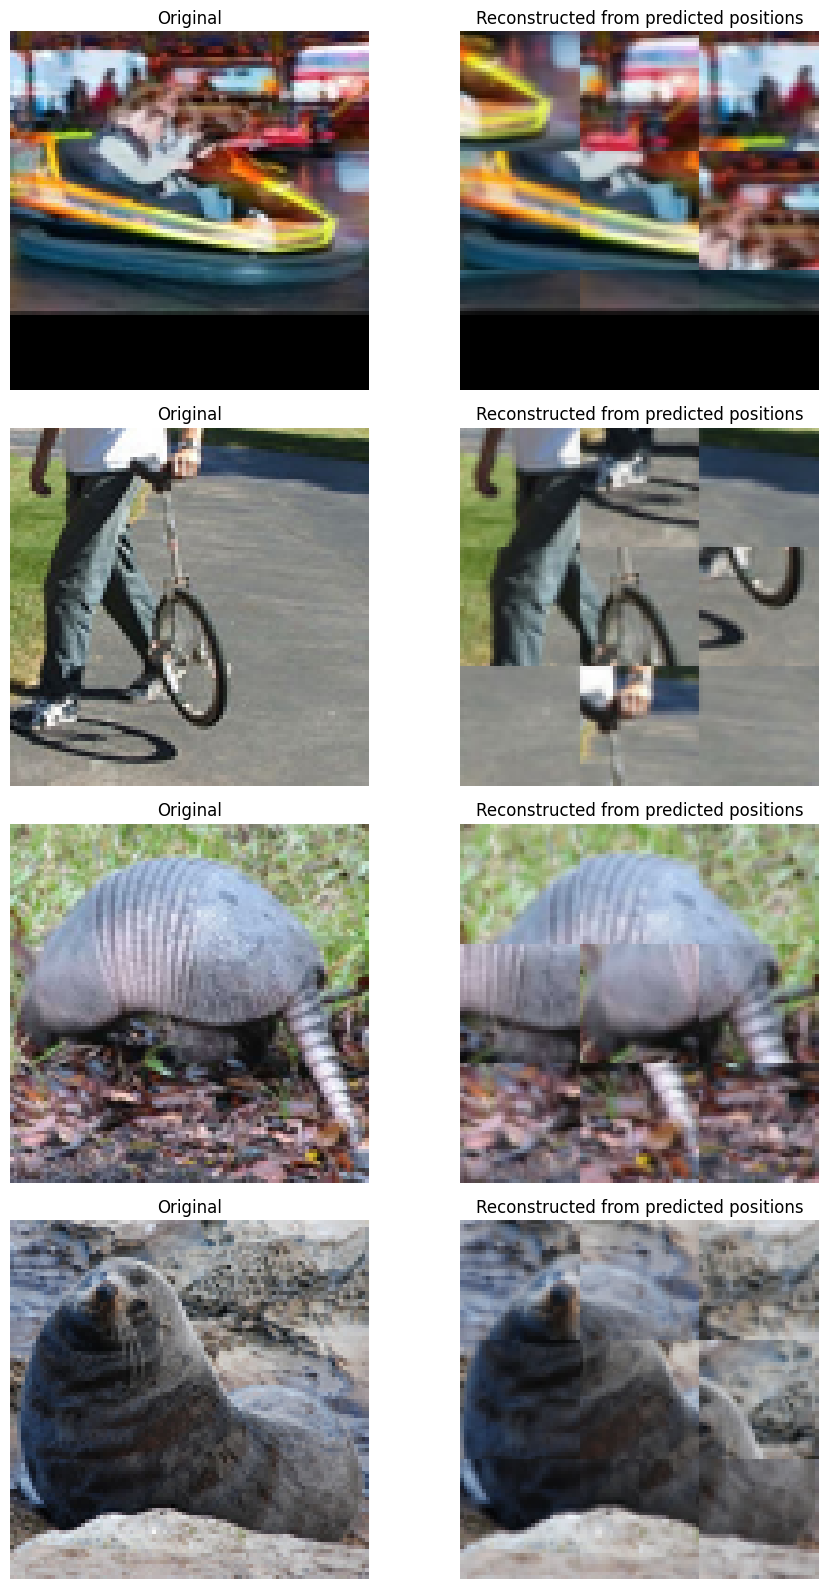

In [ ]:
# ============================================================
# VISUALIZE ORIGINAL VS PREDICTED PUZZLE RECONSTRUCTION
# ============================================================

from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Important: test generator without shuffling images
test_generator = PatchPermutationGenerator(
    test_images,
    batch_size=16,
    shuffle=False
)

def sinkhorn_to_permutation(pred_matrix):
    row_ind, col_ind = linear_sum_assignment(-pred_matrix)

    positions = np.zeros(9, dtype=int)
    positions[row_ind] = col_ind

    return positions


def reconstruct_84_from_positions(patches, positions):
    """
    Reconstructs an 84x84 image from 9 patches of 28x28.
    """

    image = np.zeros((84, 84, 3), dtype=np.float32)

    for patch_idx in range(9):
        pos = positions[patch_idx]

        row = pos // 3
        col = pos % 3

        image[
            row*28:(row+1)*28,
            col*28:(col+1)*28,
            :
        ] = patches[patch_idx]

    return image


# Get batch
x_batch, y_batch = test_generator[0]

# Predict positions
preds = model.predict(x_batch)

true_positions = np.argmax(y_batch, axis=-1)

pred_positions = []

for i in range(len(x_batch)):
    pred_positions.append(
        sinkhorn_to_permutation(preds[i])
    )

pred_positions = np.array(pred_positions)

print("True positions:", true_positions[0])
print("Predicted positions:", pred_positions[0])
print("Position accuracy:", np.mean(true_positions == pred_positions))

# Plot original vs reconstructed
num_examples = 4

plt.figure(figsize=(10, 4 * num_examples))

for i in range(num_examples):

    original = test_images[i].astype("float32") / 255.0

    reconstructed_84 = reconstruct_84_from_positions(
        x_batch[i],
        pred_positions[i]
    )

    reconstructed_96 = tf.image.resize(
        reconstructed_84,
        (96, 96)
    ).numpy()

    plt.subplot(num_examples, 2, 2*i + 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(num_examples, 2, 2*i + 2)
    plt.imshow(reconstructed_96)
    plt.title("Reconstructed from predicted positions")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# COMPUTE MAE OF PUZZLE RECONSTRUCTION MODEL
# ============================================================

from scipy.optimize import linear_sum_assignment
import numpy as np
import tensorflow as tf

def sinkhorn_to_permutation(pred_matrix):
    row_ind, col_ind = linear_sum_assignment(-pred_matrix)

    positions = np.zeros(9, dtype=int)
    positions[row_ind] = col_ind

    return positions


def reconstruct_84_from_positions(patches, positions):
    image = np.zeros((84, 84, 3), dtype=np.float32)

    for patch_idx in range(9):
        pos = positions[patch_idx]

        row = pos // 3
        col = pos % 3

        image[
            row*28:(row+1)*28,
            col*28:(col+1)*28,
            :
        ] = patches[patch_idx]

    return image


mae_values = []

# Make sure the test generator is not shuffled
test_generator = PatchPermutationGenerator(
    test_images,
    batch_size=16,
    shuffle=False
)

for batch_idx in range(len(test_generator)):

    x_batch, y_batch = test_generator[batch_idx]

    preds = model.predict(x_batch, verbose=0)

    for i in range(len(x_batch)):

        pred_positions = sinkhorn_to_permutation(preds[i])

        reconstructed_84 = reconstruct_84_from_positions(
            x_batch[i],
            pred_positions
        )

        reconstructed_96 = tf.image.resize(
            reconstructed_84,
            (96, 96)
        ).numpy()

        original = test_images[
            batch_idx * test_generator.batch_size + i
        ].astype("float32") / 255.0

        mae = np.mean(
            np.abs(original - reconstructed_96)
        )

        mae_values.append(mae)

mae_values = np.array(mae_values)

print("Mean MAE:", np.mean(mae_values))
print("Std MAE:", np.std(mae_values))
print("Baseline MAE: 0.188")

Mean MAE: 0.1312486
Std MAE: 0.062877364
Baseline MAE: 0.188


In [ ]:
#The proposed neural-network-based puzzle solver achieved a mean MAE of 0.132, substantially outperforming the baseline reconstruction method, which obtained an MAE of 0.188.

#This represents an improvement of approximately 30% in reconstruction error. The result indicates that learning the spatial arrangement of image patches is considerably more effective than the non-trainable mean-patch reconstruction strategy provided as baseline.

#The obtained standard deviation of 0.064 suggests that performance is relatively consistent across different test images, although some difficult samples still produce larger reconstruction errors.

Model: "edge_pairwise_attention_sinkhorn_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches_input       │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 9, 28, 28, │        896 │ patches_input[0]… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 9, 28, 28, │        128 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 9, 14, 14, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 9, 14, 14, │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 9, 14, 14, │        256 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 9, 7, 7,   │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 9, 7, 7,   │     73,856 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, 9, 7, 7,   │        512 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edge_feature_layer  │ (None, 9, 1344)   │          0 │ patches_input[0]… │
│ (EdgeFeatureLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_8  │ (None, 9, 7, 7,   │    295,168 │ time_distributed… │
│ (TimeDistributed)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_11 │ (None, 9, 256)    │    344,320 │ edge_feature_lay… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pairwise_edge_comp… │ (None, 9, 18)     │          0 │ patches_input[0]… │
│ (PairwiseEdgeCompa… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 9, 7, 7,   │      1,024 │ time_distributed… │
│ (TimeDistributed)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_12 │ (None, 9, 256)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_14 │ (None, 9, 64)     │      1,216 │ pairwise_edge_co… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_10 │ (None, 9, 256)    │          0 │ time_distributed

 Total params: 1,944,393 (7.42 MB)

 Trainable params: 1,943,433 (7.41 MB)

 Non-trainable params: 960 (3.75 KB)

Total parameters: 1944393
Epoch 1/100


I0000 00:00:1780415200.632088     296 service.cc:152] XLA service 0x795b34002b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780415200.632131     296 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780415200.632136     296 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780415205.243883     296 cuda_dnn.cc:529] Loaded cuDNN version 91002


   5/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - accuracy: 0.1339 - loss: 3.0132  

I0000 00:00:1780415243.025542     296 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 89s 27ms/step - accuracy: 0.3110 - loss: 1.7524 - val_accuracy: 0.3824 - val_loss: 1.6436 - learning_rate: 3.0000e-04
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.4384 - loss: 1.4408 - val_accuracy: 0.4473 - val_loss: 1.4582 - learning_rate: 3.0000e-04
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.5294 - loss: 1.2232 - val_accuracy: 0.4567 - val_loss: 1.5966 - learning_rate: 3.0000e-04
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.6205 - loss: 0.9982 - val_accuracy: 0.4482 - val_loss: 1.7392 - learning_rate: 3.0000e-04
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.7132 - loss: 0.7722 - val_accuracy: 0.4420 - val_loss: 2.0785 - learning_rate: 3.0000e-04
Epoch 6/100
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7660 - loss: 0.6296
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/s

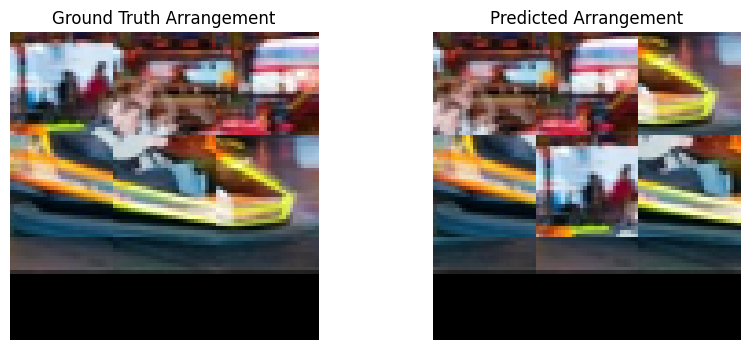

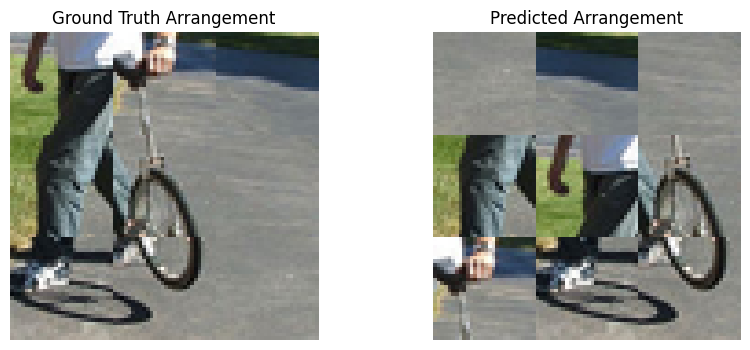

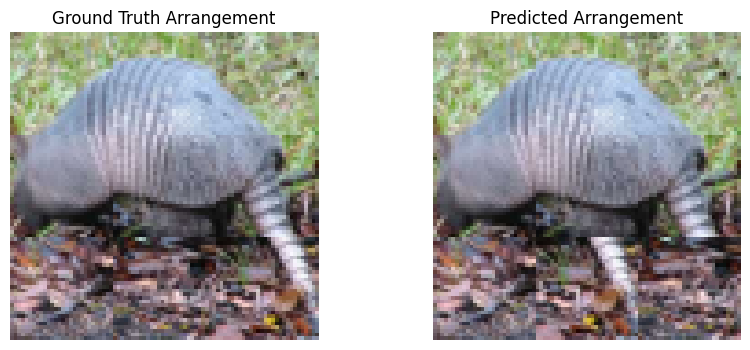

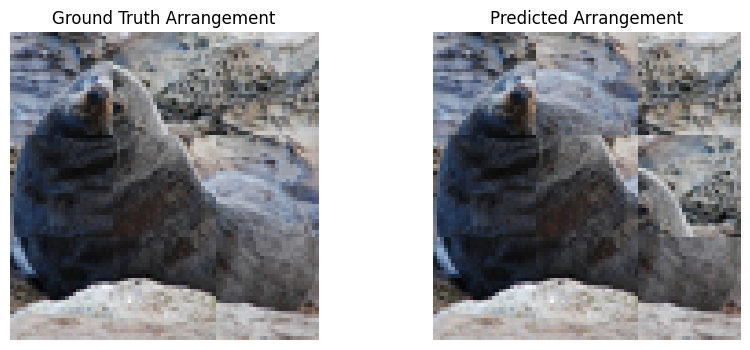

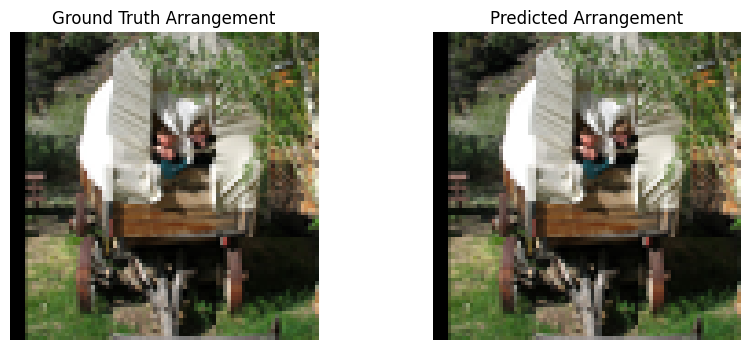

In [ ]:
#VERSION MEJORADA!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

#para casos como los de la bici:

#añade señal explícita de compatibilidad de bordes

# ============================================================
# EDGE-AWARE + PAIRWISE COMPATIBILITY + ATTENTION SINKHORN MODEL
# ============================================================

import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

from keras import layers
from keras.utils import PyDataset
from scipy.optimize import linear_sum_assignment


# ============================================================
# GENERATOR: PATCHES + PERMUTATION MATRIX
# ============================================================

class PatchPermutationGenerator(PyDataset):

    def __init__(
        self,
        images,
        batch_size=16,
        patch_size=32,
        crop_size=28,
        shuffle=True,
        repeat_factor=1,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.images = images.astype("float32") / 255.0
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.repeat_factor = repeat_factor
        self.indices = np.arange(len(images))

        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(
            np.ceil(
                len(self.indices) * self.repeat_factor / self.batch_size
            )
        )

    def __getitem__(self, idx):

        if self.repeat_factor > 1:
            batch_idx = np.random.choice(
                self.indices,
                size=self.batch_size,
                replace=True
            )
        else:
            batch_idx = self.indices[
                idx * self.batch_size:(idx + 1) * self.batch_size
            ]

        bs = len(batch_idx)

        X = np.zeros((bs, 9, 28, 28, 3), dtype=np.float32)
        Y = np.zeros((bs, 9, 9), dtype=np.float32)

        for i, img_idx in enumerate(batch_idx):

            img = self.images[img_idx]
            patches = []

            for r in range(3):
                for c in range(3):

                    y = r * self.patch_size
                    x = c * self.patch_size

                    patch = img[
                        y:y + self.patch_size,
                        x:x + self.patch_size,
                        :
                    ]

                    margin = (self.patch_size - self.crop_size) // 2

                    patch = patch[
                        margin:margin + self.crop_size,
                        margin:margin + self.crop_size,
                        :
                    ]

                    patches.append(patch)

            order = np.random.permutation(9)

            for slot, original_pos in enumerate(order):
                X[i, slot] = patches[original_pos]
                Y[i, slot, original_pos] = 1.0

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


# ============================================================
# CREATE GENERATORS
# ============================================================

train_generator = PatchPermutationGenerator(
    train_images,
    batch_size=16,
    repeat_factor=4,
    shuffle=True
)

val_generator = PatchPermutationGenerator(
    val_images,
    batch_size=16,
    repeat_factor=1,
    shuffle=False
)

test_generator = PatchPermutationGenerator(
    test_images,
    batch_size=16,
    repeat_factor=1,
    shuffle=False
)


# ============================================================
# STABLE SINKHORN LAYER
# ============================================================

class SinkhornLayer(layers.Layer):

    def __init__(
        self,
        iterations=25,
        temperature=0.5,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.iterations = iterations
        self.temperature = temperature

    def call(self, logits):

        logits = logits / self.temperature

        logits = logits - tf.reduce_max(
            logits,
            axis=[-1, -2],
            keepdims=True
        )

        x = tf.exp(logits)

        for _ in range(self.iterations):

            x = x / (
                tf.reduce_sum(
                    x,
                    axis=-1,
                    keepdims=True
                ) + 1e-8
            )

            x = x / (
                tf.reduce_sum(
                    x,
                    axis=-2,
                    keepdims=True
                ) + 1e-8
            )

        return x


# ============================================================
# EDGE BAND FEATURE LAYER
# ============================================================

class EdgeFeatureLayer(layers.Layer):

    def __init__(
        self,
        band_size=4,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.band_size = band_size

    def call(self, patches):

        b = self.band_size

        top = patches[:, :, :b, :, :]
        bottom = patches[:, :, -b:, :, :]
        left = patches[:, :, :, :b, :]
        right = patches[:, :, :, -b:, :]

        top = tf.reshape(top, (-1, 9, b * 28 * 3))
        bottom = tf.reshape(bottom, (-1, 9, b * 28 * 3))
        left = tf.reshape(left, (-1, 9, 28 * b * 3))
        right = tf.reshape(right, (-1, 9, 28 * b * 3))

        edges = tf.concat(
            [top, bottom, left, right],
            axis=-1
        )

        return edges

    def compute_output_shape(self, input_shape):
        return (
            input_shape[0],
            9,
            self.band_size * 28 * 3 * 4
        )


# ============================================================
# PAIRWISE EDGE COMPATIBILITY LAYER
# ============================================================

class PairwiseEdgeCompatibilityLayer(layers.Layer):

    def call(self, patches):

        # patches: (batch, 9, 28, 28, 3)

        top = patches[:, :, 0, :, :]
        bottom = patches[:, :, -1, :, :]
        left = patches[:, :, :, 0, :]
        right = patches[:, :, :, -1, :]

        top = tf.reshape(top, (-1, 9, 28 * 3))
        bottom = tf.reshape(bottom, (-1, 9, 28 * 3))
        left = tf.reshape(left, (-1, 9, 28 * 3))
        right = tf.reshape(right, (-1, 9, 28 * 3))

        horizontal_diff = tf.abs(
            tf.expand_dims(right, axis=2)
            - tf.expand_dims(left, axis=1)
        )

        vertical_diff = tf.abs(
            tf.expand_dims(bottom, axis=2)
            - tf.expand_dims(top, axis=1)
        )

        horizontal_score = tf.reduce_mean(
            horizontal_diff,
            axis=-1
        )

        vertical_score = tf.reduce_mean(
            vertical_diff,
            axis=-1
        )

        compatibility = tf.concat(
            [
                horizontal_score,
                vertical_score
            ],
            axis=-1
        )

        return compatibility

    def compute_output_shape(self, input_shape):
        return (
            input_shape[0],
            9,
            18
        )


# ============================================================
# TRANSFORMER BLOCK
# ============================================================

def transformer_block(
    x,
    num_heads=4,
    key_dim=64,
    ff_dim=512,
    dropout=0.1
):

    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout
    )(x, x)

    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    ff = layers.Dense(
        ff_dim,
        activation="relu"
    )(x)

    ff = layers.Dropout(dropout)(ff)

    ff = layers.Dense(
        x.shape[-1]
    )(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    return x


# ============================================================
# MODEL
# ============================================================

def build_edge_pairwise_attention_sinkhorn_model():

    inputs = keras.Input(
        shape=(9, 28, 28, 3),
        name="patches_input"
    )

    # ----------------------------
    # CNN GLOBAL PATCH FEATURES
    # ----------------------------

    x = layers.TimeDistributed(
        layers.Conv2D(
            32,
            3,
            padding="same",
            activation="relu"
        )
    )(inputs)

    x = layers.TimeDistributed(
        layers.BatchNormalization()
    )(x)

    x = layers.TimeDistributed(
        layers.MaxPooling2D()
    )(x)

    x = layers.TimeDistributed(
        layers.Conv2D(
            64,
            3,
            padding="same",
            activation="relu"
        )
    )(x)

    x = layers.TimeDistributed(
        layers.BatchNormalization()
    )(x)

    x = layers.TimeDistributed(
        layers.MaxPooling2D()
    )(x)

    x = layers.TimeDistributed(
        layers.Conv2D(
            128,
            3,
            padding="same",
            activation="relu"
        )
    )(x)

    x = layers.TimeDistributed(
        layers.BatchNormalization()
    )(x)

    x = layers.TimeDistributed(
        layers.Conv2D(
            256,
            3,
            padding="same",
            activation="relu"
        )
    )(x)

    x = layers.TimeDistributed(
        layers.BatchNormalization()
    )(x)

    global_features = layers.TimeDistributed(
        layers.GlobalAveragePooling2D()
    )(x)

    # ----------------------------
    # EDGE BAND FEATURES
    # ----------------------------

    edge_features = EdgeFeatureLayer(
        band_size=4
    )(inputs)

    edge_features = layers.TimeDistributed(
        layers.Dense(
            256,
            activation="relu"
        )
    )(edge_features)

    edge_features = layers.TimeDistributed(
        layers.Dropout(0.15)
    )(edge_features)

    edge_features = layers.TimeDistributed(
        layers.Dense(
            128,
            activation="relu"
        )
    )(edge_features)

    # ----------------------------
    # PAIRWISE EDGE COMPATIBILITY FEATURES
    # ----------------------------

    pairwise_compatibility = PairwiseEdgeCompatibilityLayer()(
        inputs
    )

    pairwise_compatibility = layers.TimeDistributed(
        layers.Dense(
            64,
            activation="relu"
        )
    )(pairwise_compatibility)

    pairwise_compatibility = layers.TimeDistributed(
        layers.Dense(
            64,
            activation="relu"
        )
    )(pairwise_compatibility)

    # ----------------------------
    # COMBINE GLOBAL + EDGE + PAIRWISE FEATURES
    # ----------------------------

    features = layers.Concatenate(axis=-1)(
        [
            global_features,
            edge_features,
            pairwise_compatibility
        ]
    )

    features = layers.TimeDistributed(
        layers.Dense(
            256,
            activation="relu"
        )
    )(features)

    features = layers.Dropout(
        0.2
    )(features)

    # ----------------------------
    # SELF-ATTENTION BETWEEN PATCHES
    # ----------------------------

    context = transformer_block(
        features,
        num_heads=4,
        key_dim=64,
        ff_dim=512,
        dropout=0.1
    )

    context = transformer_block(
        context,
        num_heads=4,
        key_dim=64,
        ff_dim=512,
        dropout=0.1
    )

    # ----------------------------
    # POSITION SCORES
    # ----------------------------

    logits = layers.TimeDistributed(
        layers.Dense(9)
    )(context)

    # ----------------------------
    # SINKHORN PERMUTATION MATRIX
    # ----------------------------

    outputs = SinkhornLayer(
        iterations=25,
        temperature=0.5,
        name="sinkhorn_permutation"
    )(logits)

    model = keras.Model(
        inputs,
        outputs,
        name="edge_pairwise_attention_sinkhorn_model"
    )

    return model


# ============================================================
# CREATE MODEL
# ============================================================

tf.keras.backend.clear_session()

model = build_edge_pairwise_attention_sinkhorn_model()

model.summary()

print(
    "Total parameters:",
    model.count_params()
)


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# CALLBACKS
# ============================================================

callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=12,
        restore_best_weights=True,
        mode="max"
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        mode="min",
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "best_edge_pairwise_attention_sinkhorn.weights.h5",
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        mode="max"
    )
]


# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=callbacks
)


# ============================================================
# EVALUATE MODEL
# ============================================================

results = model.evaluate(
    test_generator,
    verbose=1
)

print("Test loss:", results[0])
print("Test soft accuracy:", results[1])


# ============================================================
# HUNGARIAN: SOFT SINKHORN TO HARD PERMUTATION
# ============================================================

def sinkhorn_to_permutation(pred_matrix):

    row_ind, col_ind = linear_sum_assignment(
        -pred_matrix
    )

    positions = np.zeros(
        9,
        dtype=int
    )

    positions[row_ind] = col_ind

    return positions


def batch_sinkhorn_to_permutation(pred_batch):

    pred_positions = []

    for i in range(pred_batch.shape[0]):

        pred_positions.append(
            sinkhorn_to_permutation(
                pred_batch[i]
            )
        )

    return np.array(
        pred_positions,
        dtype=np.int32
    )


# ============================================================
# HARD PERMUTATION ACCURACY
# ============================================================

def hard_permutation_accuracy(
    model,
    generator,
    max_batches=None
):

    total_correct = 0
    total_positions = 0
    total_full_puzzles = 0
    total_puzzles = 0

    n_batches = len(generator)

    if max_batches is not None:
        n_batches = min(
            n_batches,
            max_batches
        )

    for batch_idx in range(n_batches):

        x_batch, y_batch = generator[batch_idx]

        pred = model.predict(
            x_batch,
            verbose=0
        )

        if isinstance(pred, dict):
            pred = list(pred.values())[0]

        true_positions = np.argmax(
            y_batch,
            axis=-1
        )

        pred_positions = batch_sinkhorn_to_permutation(
            pred
        )

        total_correct += np.sum(
            true_positions == pred_positions
        )

        total_positions += np.prod(
            true_positions.shape
        )

        total_full_puzzles += np.sum(
            np.all(
                true_positions == pred_positions,
                axis=1
            )
        )

        total_puzzles += true_positions.shape[0]

    position_accuracy = total_correct / total_positions
    full_puzzle_accuracy = total_full_puzzles / total_puzzles

    return position_accuracy, full_puzzle_accuracy


test_position_acc, test_full_puzzle_acc = hard_permutation_accuracy(
    model,
    test_generator
)

print(
    "Hard position accuracy:",
    test_position_acc
)

print(
    "Full puzzle accuracy:",
    test_full_puzzle_acc
)


# ============================================================
# INSPECT ONE PREDICTION
# ============================================================

x_batch, y_batch = test_generator[0]

pred = model.predict(
    x_batch,
    verbose=1
)

if isinstance(pred, dict):
    pred = list(pred.values())[0]

true_positions = np.argmax(
    y_batch,
    axis=-1
)

pred_positions = batch_sinkhorn_to_permutation(
    pred
)

print("TRUE POSITIONS")
print(true_positions[0])

print("PREDICTED POSITIONS")
print(pred_positions[0])

print(
    "Position accuracy on this batch:",
    np.mean(
        true_positions == pred_positions
    )
)

print(
    "Full puzzle accuracy on this batch:",
    np.mean(
        np.all(
            true_positions == pred_positions,
            axis=1
        )
    )
)

print(
    "Is predicted output a valid permutation?",
    sorted(
        pred_positions[0].tolist()
    ) == list(range(9))
)


# ============================================================
# REASSEMBLE PUZZLE FROM PREDICTED POSITIONS
# ============================================================

def reassemble_puzzle_84(
    patches,
    positions
):

    canvas = np.zeros(
        (84, 84, 3),
        dtype=np.float32
    )

    for patch_idx in range(9):

        pos = positions[patch_idx]

        row = pos // 3
        col = pos % 3

        y = row * 28
        x = col * 28

        canvas[
            y:y + 28,
            x:x + 28,
            :
        ] = patches[patch_idx]

    return canvas


def reassemble_batch_84(
    patches_batch,
    positions_batch
):

    reconstructed = []

    for i in range(
        patches_batch.shape[0]
    ):

        reconstructed.append(
            reassemble_puzzle_84(
                patches_batch[i],
                positions_batch[i]
            )
        )

    return np.array(
        reconstructed,
        dtype=np.float32
    )


# ============================================================
# BUILD RECONSTRUCTED PUZZLES
# ============================================================

reconstructed_84 = reassemble_batch_84(
    x_batch,
    pred_positions
)

print(
    "Reconstructed shape:",
    reconstructed_84.shape
)


# ============================================================
# RESIZE TO 96x96
# ============================================================

reconstructed_96 = tf.image.resize(
    reconstructed_84,
    (96, 96),
    method="bilinear"
).numpy()

print(
    "Reconstructed 96x96 shape:",
    reconstructed_96.shape
)


# ============================================================
# VISUALIZE RESULTS
# ============================================================

def show_reconstruction_examples(
    patches_batch,
    true_positions,
    pred_positions,
    num_examples=5
):

    for i in range(num_examples):

        gt_img = reassemble_puzzle_84(
            patches_batch[i],
            true_positions[i]
        )

        pred_img = reassemble_puzzle_84(
            patches_batch[i],
            pred_positions[i]
        )

        plt.figure(
            figsize=(10, 4)
        )

        plt.subplot(1, 2, 1)
        plt.imshow(gt_img)
        plt.title("Ground Truth Arrangement")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(pred_img)
        plt.title("Predicted Arrangement")
        plt.axis("off")

        plt.show()


show_reconstruction_examples(
    x_batch,
    true_positions,
    pred_positions,
    num_examples=5
)


The model performs particularly well when patches contain distinctive semantic structures, such as object boundaries, limbs, or textured regions. Most reconstruction errors occur in visually homogeneous areas, where multiple patches exhibit very similar appearance and provide limited spatial cues for disambiguation.

Model: "nueva_version_mejorada_neighbor_global"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches_input       │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 9, 28, 28, │        896 │ patches_input[0]… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 9, 28, 28, │        128 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 9, 14, 14, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 9, 14, 14, │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 9, 14, 14, │        256 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 9, 7, 7,   │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 9, 7, 7,   │     73,856 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, 9, 7, 7,   │        512 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edge_feature_layer  │ (None, 9, 1344)   │          0 │ patches_input[0]… │
│ (EdgeFeatureLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_8  │ (None, 9, 7, 7,   │    295,168 │ time_distributed… │
│ (TimeDistributed)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_11 │ (None, 9, 256)    │    344,320 │ edge_feature_lay… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 9, 7, 7,   │      1,024 │ time_distributed… │
│ (TimeDistributed)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_12 │ (None, 9, 256)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_10 │ (None, 9, 256)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_13 │ (None, 9, 128)    │     32,896 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 9, 384)    │          0 │ time_distributed

 Total params: 3,040,587 (11.60 MB)

 Trainable params: 3,039,627 (11.60 MB)

 Non-trainable params: 960 (3.75 KB)

Total parameters: 3040587
Epoch 1/120
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 105s 37ms/step - bottom_neighbor_binary_accuracy: 0.9258 - bottom_neighbor_loss: 0.2413 - loss: 1.9577 - right_neighbor_binary_accuracy: 0.9252 - right_neighbor_loss: 0.2494 - sinkhorn_permutation_accuracy: 0.2985 - sinkhorn_permutation_loss: 1.7860 - val_bottom_neighbor_binary_accuracy: 0.9259 - val_bottom_neighbor_loss: 0.2267 - val_loss: 1.7603 - val_right_neighbor_binary_accuracy: 0.9259 - val_right_neighbor_loss: 0.2316 - val_sinkhorn_permutation_accuracy: 0.3936 - val_sinkhorn_permutation_loss: 1.5880 - learning_rate: 3.0000e-04
Epoch 2/120
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - bottom_neighbor_binary_accuracy: 0.9260 - bottom_neighbor_loss: 0.2156 - loss: 1.6112 - right_neighbor_binary_accuracy: 0.9262 - right_neighbor_loss: 0.2230 - sinkhorn_permutation_accuracy: 0.4329 - sinkhorn_permutation_loss: 1.4577 - val_bottom_neighbor_binary_accuracy: 0.9262 - val_bottom_neighbor_loss: 0.2147 - val_loss: 1.675

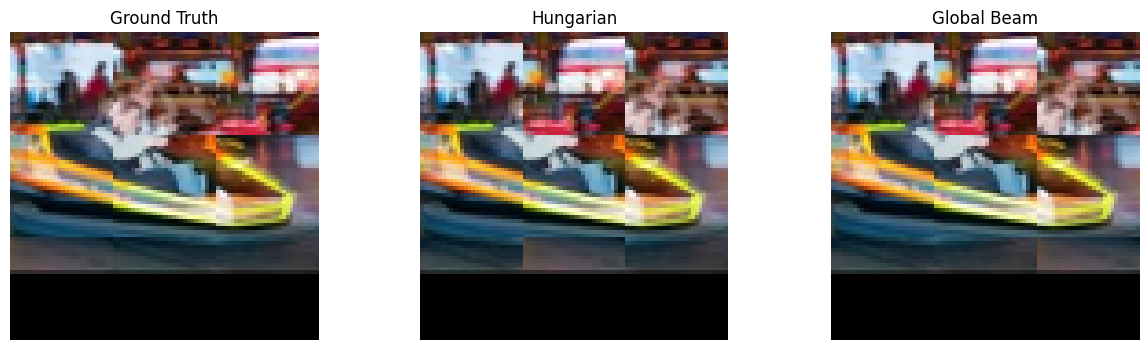

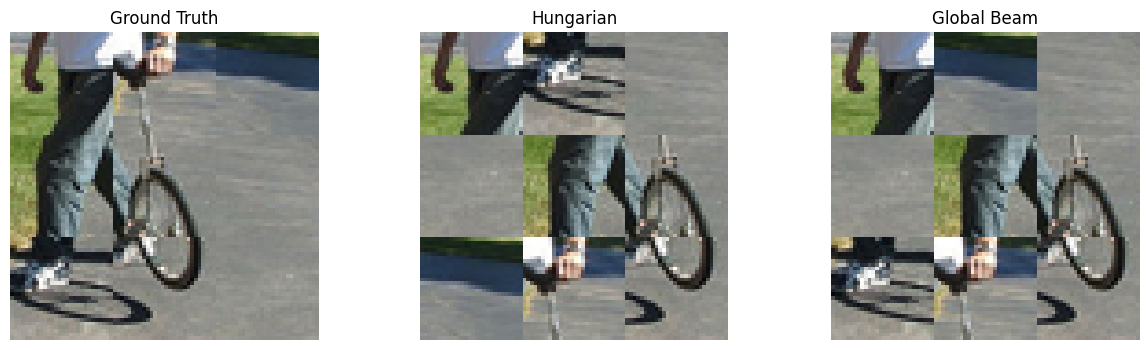

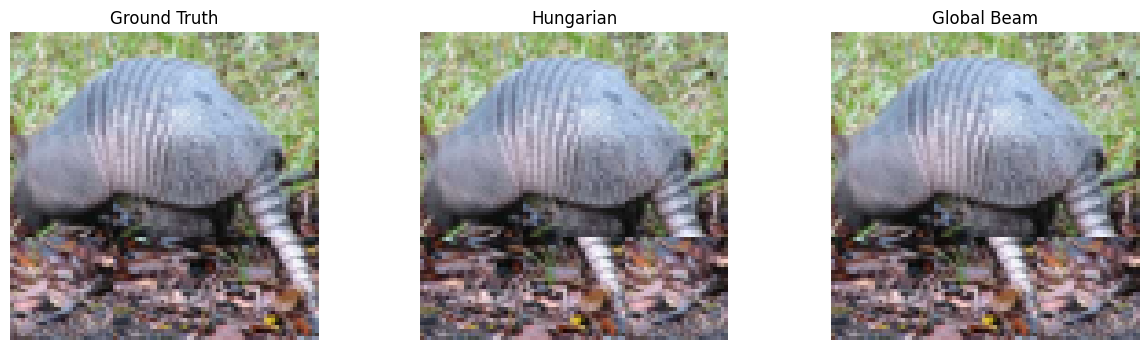

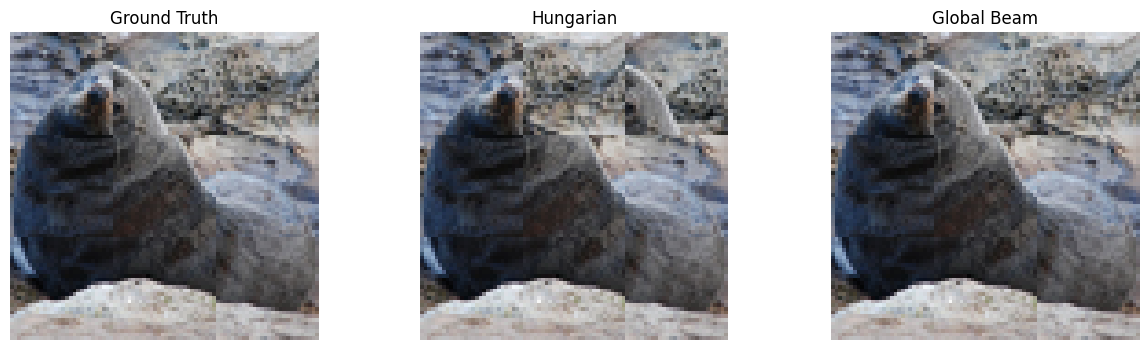

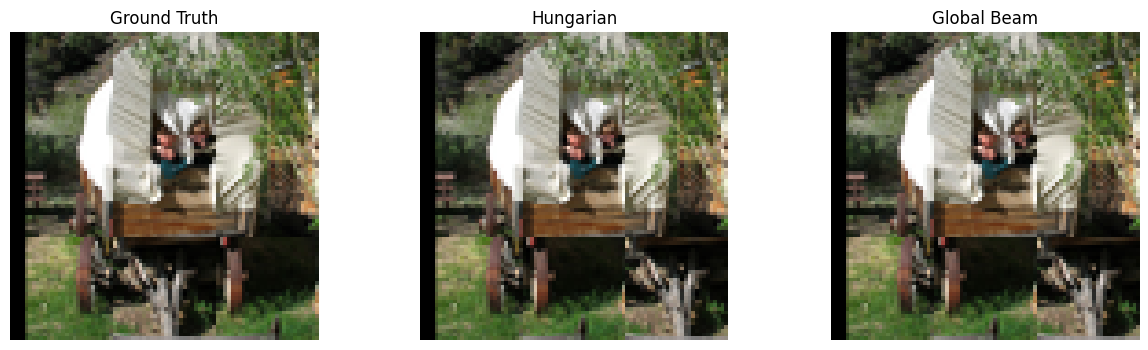

In [ ]:
#2nd new VERSION!!!!!!!!!!!!!!!!!!!!!!!!!
# ============================================================
# NUEVA VERSION MEJORADA + NEIGHBOR AUX + GLOBAL DECODING
# EDGE-AWARE ATTENTION SINKHORN POSITION MODEL
# ============================================================

import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

from keras import layers
from keras.utils import PyDataset
from scipy.optimize import linear_sum_assignment


# ============================================================
# GENERATOR: PATCHES + POSITION + NEIGHBOR TARGETS
# ============================================================

class PatchPermutationGenerator(PyDataset):

    def __init__(
        self,
        images,
        batch_size=16,
        patch_size=32,
        crop_size=28,
        shuffle=True,
        repeat_factor=1,
        use_augmentation=False,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.images = images.astype("float32") / 255.0
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.repeat_factor = repeat_factor
        self.use_augmentation = use_augmentation
        self.indices = np.arange(len(images))

        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(
            np.ceil(
                len(self.indices) * self.repeat_factor / self.batch_size
            )
        )

    def augment_patch(self, patch):

        if not self.use_augmentation:
            return patch

        # Augmentations suaves que NO rompen la posición espacial.
        brightness = np.random.uniform(-0.06, 0.06)
        contrast = np.random.uniform(0.9, 1.1)
        noise = np.random.normal(0, 0.01, patch.shape)

        patch = patch + brightness
        patch = (patch - 0.5) * contrast + 0.5
        patch = patch + noise

        patch = np.clip(patch, 0.0, 1.0)

        return patch.astype(np.float32)

    def __getitem__(self, idx):

        if self.repeat_factor > 1:
            batch_idx = np.random.choice(
                self.indices,
                size=self.batch_size,
                replace=True
            )
        else:
            batch_idx = self.indices[
                idx*self.batch_size:(idx+1)*self.batch_size
            ]

        bs = len(batch_idx)

        X = np.zeros((bs, 9, 28, 28, 3), dtype=np.float32)

        Y_position = np.zeros((bs, 9, 9), dtype=np.float32)
        Y_right = np.zeros((bs, 9, 9), dtype=np.float32)
        Y_bottom = np.zeros((bs, 9, 9), dtype=np.float32)

        for i, img_idx in enumerate(batch_idx):

            img = self.images[img_idx]
            patches = []

            for r in range(3):
                for c in range(3):

                    y = r * self.patch_size
                    x = c * self.patch_size

                    patch = img[
                        y:y+self.patch_size,
                        x:x+self.patch_size,
                        :
                    ]

                    margin = (self.patch_size - self.crop_size) // 2

                    patch = patch[
                        margin:margin+self.crop_size,
                        margin:margin+self.crop_size,
                        :
                    ]

                    patch = self.augment_patch(patch)

                    patches.append(patch)

            order = np.random.permutation(9)

            # order[slot] = original_pos
            # slot = índice de la pieza mezclada
            # original_pos = posición real 0..8

            original_to_scrambled = np.zeros(9, dtype=np.int32)

            for slot, original_pos in enumerate(order):

                X[i, slot] = patches[original_pos]
                Y_position[i, slot, original_pos] = 1.0

                original_to_scrambled[original_pos] = slot

            # Targets de vecinos en espacio de piezas mezcladas.
            # Y_right[a, b] = 1 si b va a la derecha de a.
            # Y_bottom[a, b] = 1 si b va debajo de a.

            for pos in range(9):

                row = pos // 3
                col = pos % 3

                patch_a = original_to_scrambled[pos]

                if col < 2:
                    right_pos = pos + 1
                    patch_b = original_to_scrambled[right_pos]
                    Y_right[i, patch_a, patch_b] = 1.0

                if row < 2:
                    bottom_pos = pos + 3
                    patch_b = original_to_scrambled[bottom_pos]
                    Y_bottom[i, patch_a, patch_b] = 1.0

        return X, {
            "sinkhorn_permutation": Y_position,
            "right_neighbor": Y_right,
            "bottom_neighbor": Y_bottom,
        }

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indices)


# ============================================================
# CREATE GENERATORS
# ============================================================

train_generator = PatchPermutationGenerator(
    train_images,
    batch_size=16,
    repeat_factor=4,
    shuffle=True,
    use_augmentation=True
)

val_generator = PatchPermutationGenerator(
    val_images,
    batch_size=16,
    repeat_factor=1,
    shuffle=False,
    use_augmentation=False
)

test_generator = PatchPermutationGenerator(
    test_images,
    batch_size=16,
    repeat_factor=1,
    shuffle=False,
    use_augmentation=False
)


# ============================================================
# STABLE SINKHORN LAYER
# ============================================================

class SinkhornLayer(layers.Layer):

    def __init__(
        self,
        iterations=25,
        temperature=0.5,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.iterations = iterations
        self.temperature = temperature

    def call(self, logits):

        logits = logits / self.temperature

        logits = logits - tf.reduce_max(
            logits,
            axis=-1,
            keepdims=True
        )

        x = tf.exp(logits)

        for _ in range(self.iterations):

            x = x / (
                tf.reduce_sum(
                    x,
                    axis=-1,
                    keepdims=True
                ) + 1e-8
            )

            x = x / (
                tf.reduce_sum(
                    x,
                    axis=-2,
                    keepdims=True
                ) + 1e-8
            )

        return x


# ============================================================
# EDGE BAND FEATURE LAYER
# ============================================================

class EdgeFeatureLayer(layers.Layer):

    def __init__(
        self,
        band_size=4,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.band_size = band_size

    def call(self, patches):

        b = self.band_size

        top = patches[:, :, :b, :, :]
        bottom = patches[:, :, -b:, :, :]
        left = patches[:, :, :, :b, :]
        right = patches[:, :, :, -b:, :]

        top = tf.reshape(
            top,
            (-1, 9, b * 28 * 3)
        )

        bottom = tf.reshape(
            bottom,
            (-1, 9, b * 28 * 3)
        )

        left = tf.reshape(
            left,
            (-1, 9, 28 * b * 3)
        )

        right = tf.reshape(
            right,
            (-1, 9, 28 * b * 3)
        )

        edges = tf.concat(
            [
                top,
                bottom,
                left,
                right
            ],
            axis=-1
        )

        return edges

    def compute_output_shape(self, input_shape):

        return (
            input_shape[0],
            9,
            self.band_size * 28 * 3 * 4
        )


# ============================================================
# TRANSFORMER BLOCK
# ============================================================

def transformer_block(
    x,
    num_heads=4,
    key_dim=64,
    ff_dim=512,
    dropout=0.1
):

    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout
    )(x, x)

    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    ff = layers.Dense(
        ff_dim,
        activation="relu"
    )(x)

    ff = layers.Dropout(dropout)(ff)

    ff = layers.Dense(
        x.shape[-1]
    )(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    return x


# ============================================================
# PAIRWISE NEIGHBOR HEAD
# ============================================================

def pairwise_neighbor_head(
    context,
    name
):
    """
    context:
        (batch, 9, feature_dim)

    returns:
        (batch, 9, 9)

    output[a, b] = probability that patch b is neighbor of patch a
    """

    feature_dim = context.shape[-1]

    a = layers.Lambda(
        lambda t: tf.expand_dims(t, axis=2)
    )(context)

    b = layers.Lambda(
        lambda t: tf.expand_dims(t, axis=1)
    )(context)

    a = layers.Lambda(
        lambda t: tf.tile(t, [1, 1, 9, 1])
    )(a)

    b = layers.Lambda(
        lambda t: tf.tile(t, [1, 9, 1, 1])
    )(b)

    pair = layers.Concatenate(axis=-1)(
        [
            a,
            b,
            layers.Subtract()([a, b]),
            layers.Multiply()([a, b])
        ]
    )

    pair = layers.Dense(
        256,
        activation="relu"
    )(pair)

    pair = layers.Dropout(
        0.15
    )(pair)

    pair = layers.Dense(
        128,
        activation="relu"
    )(pair)

    scores = layers.Dense(
        1,
        activation="sigmoid"
    )(pair)

    scores = layers.Reshape(
        (9, 9),
        name=name
    )(scores)

    return scores


# ============================================================
# MODEL
# ============================================================

def build_edge_aware_sinkhorn_model():

    inputs = keras.Input(
        shape=(9, 28, 28, 3),
        name="patches_input"
    )

    # ----------------------------
    # CNN GLOBAL PATCH FEATURES
    # ----------------------------

    x = layers.TimeDistributed(
        layers.Conv2D(
            32,
            3,
            padding="same",
            activation="relu"
        )
    )(inputs)

    x = layers.TimeDistributed(
        layers.BatchNormalization()
    )(x)

    x = layers.TimeDistributed(
        layers.MaxPooling2D()
    )(x)

    x = layers.TimeDistributed(
        layers.Conv2D(
            64,
            3,
            padding="same",
            activation="relu"
        )
    )(x)

    x = layers.TimeDistributed(
        layers.BatchNormalization()
    )(x)

    x = layers.TimeDistributed(
        layers.MaxPooling2D()
    )(x)

    x = layers.TimeDistributed(
        layers.Conv2D(
            128,
            3,
            padding="same",
            activation="relu"
        )
    )(x)

    x = layers.TimeDistributed(
        layers.BatchNormalization()
    )(x)

    x = layers.TimeDistributed(
        layers.Conv2D(
            256,
            3,
            padding="same",
            activation="relu"
        )
    )(x)

    x = layers.TimeDistributed(
        layers.BatchNormalization()
    )(x)

    global_features = layers.TimeDistributed(
        layers.GlobalAveragePooling2D()
    )(x)

    # ----------------------------
    # EDGE BAND FEATURES
    # ----------------------------

    edge_features = EdgeFeatureLayer(
        band_size=4
    )(inputs)

    edge_features = layers.TimeDistributed(
        layers.Dense(
            256,
            activation="relu"
        )
    )(edge_features)

    edge_features = layers.TimeDistributed(
        layers.Dropout(0.15)
    )(edge_features)

    edge_features = layers.TimeDistributed(
        layers.Dense(
            128,
            activation="relu"
        )
    )(edge_features)

    # ----------------------------
    # COMBINE GLOBAL + EDGE FEATURES
    # ----------------------------

    features = layers.Concatenate(axis=-1)(
        [
            global_features,
            edge_features
        ]
    )

    features = layers.TimeDistributed(
        layers.Dense(
            256,
            activation="relu"
        )
    )(features)

    features = layers.Dropout(
        0.2
    )(features)

    # ----------------------------
    # SELF-ATTENTION BETWEEN PATCHES
    # ----------------------------

    context = transformer_block(
        features,
        num_heads=4,
        key_dim=64,
        ff_dim=512,
        dropout=0.1
    )

    context = transformer_block(
        context,
        num_heads=4,
        key_dim=64,
        ff_dim=512,
        dropout=0.1
    )

    context = transformer_block(
        context,
        num_heads=4,
        key_dim=64,
        ff_dim=512,
        dropout=0.1
    )

    # ----------------------------
    # POSITION SCORES
    # ----------------------------

    logits = layers.TimeDistributed(
        layers.Dense(9)
    )(context)

    sinkhorn_output = SinkhornLayer(
        iterations=25,
        temperature=0.5,
        name="sinkhorn_permutation"
    )(logits)

    # ----------------------------
    # NEIGHBOR SCORES
    # ----------------------------

    right_output = pairwise_neighbor_head(
        context,
        name="right_neighbor"
    )

    bottom_output = pairwise_neighbor_head(
        context,
        name="bottom_neighbor"
    )

    model = keras.Model(
        inputs,
        {
            "sinkhorn_permutation": sinkhorn_output,
            "right_neighbor": right_output,
            "bottom_neighbor": bottom_output,
        },
        name="nueva_version_mejorada_neighbor_global"
    )

    return model


# ============================================================
# CREATE MODEL
# ============================================================

tf.keras.backend.clear_session()

model = build_edge_aware_sinkhorn_model()

model.summary()

print(
    "Total parameters:",
    model.count_params()
)


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss={
        "sinkhorn_permutation": "categorical_crossentropy",
        "right_neighbor": "binary_crossentropy",
        "bottom_neighbor": "binary_crossentropy",
    },
    loss_weights={
        "sinkhorn_permutation": 1.0,
        "right_neighbor": 0.35,
        "bottom_neighbor": 0.35,
    },
    metrics={
        "sinkhorn_permutation": ["accuracy"],
        "right_neighbor": ["binary_accuracy"],
        "bottom_neighbor": ["binary_accuracy"],
    }
)


# ============================================================
# CALLBACKS
# ============================================================

callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_sinkhorn_permutation_accuracy",
        patience=14,
        restore_best_weights=True,
        mode="max"
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        mode="min",
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "best_nueva_version_mejorada_neighbor_global.weights.h5",
        monitor="val_sinkhorn_permutation_accuracy",
        save_best_only=True,
        save_weights_only=True,
        mode="max"
    )
]


# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=120,
    callbacks=callbacks
)


# ============================================================
# EVALUATE MODEL
# ============================================================

results = model.evaluate(
    test_generator,
    verbose=1
)

print("Test results:")
print(results)


# ============================================================
# HUNGARIAN DECODER
# ============================================================

def sinkhorn_to_permutation(pred_matrix):
    """
    Converts a soft 9x9 Sinkhorn matrix into a valid hard permutation.

    pred_matrix:
        shape (9, 9)

    returns:
        positions[i] = predicted original position of scrambled patch i
    """

    row_ind, col_ind = linear_sum_assignment(
        -pred_matrix
    )

    positions = np.zeros(
        9,
        dtype=int
    )

    positions[row_ind] = col_ind

    return positions


def batch_sinkhorn_to_permutation(pred_batch):

    pred_positions = []

    for i in range(pred_batch.shape[0]):

        pred_positions.append(
            sinkhorn_to_permutation(
                pred_batch[i]
            )
        )

    return np.array(
        pred_positions,
        dtype=np.int32
    )


# ============================================================
# GLOBAL BEAM SEARCH DECODER
# ============================================================

def decode_global_beam_search(
    position_probs,
    right_probs,
    bottom_probs,
    beam_width=200,
    alpha=0.8,
    beta=0.8,
    eps=1e-8
):
    """
    Builds a 3x3 puzzle using:
        position probabilities
        right-neighbor probabilities
        bottom-neighbor probabilities

    position_probs:
        (9, 9), position_probs[patch, position]

    right_probs:
        (9, 9), right_probs[a, b] = probability b is right of a

    bottom_probs:
        (9, 9), bottom_probs[a, b] = probability b is below a

    returns:
        positions[patch] = predicted position
    """

    log_pos = np.log(position_probs + eps)
    log_right = np.log(right_probs + eps)
    log_bottom = np.log(bottom_probs + eps)

    # Cada estado:
    # (score, placed_patches)
    # placed_patches[pos] = patch colocado en esa posición
    beam = [
        (0.0, [])
    ]

    for pos in range(9):

        row = pos // 3
        col = pos % 3

        new_beam = []

        for score, placed in beam:

            used = set(placed)

            for patch in range(9):

                if patch in used:
                    continue

                new_score = score
                new_score += log_pos[patch, pos]

                # Vecino izquierdo ya colocado.
                # Si colocamos patch en pos, y existe pos-1,
                # entonces patch debe ser right_neighbor[left_patch].
                if col > 0:

                    left_patch = placed[pos - 1]

                    new_score += alpha * log_right[
                        left_patch,
                        patch
                    ]

                # Vecino superior ya colocado.
                # Si colocamos patch en pos, y existe pos-3,
                # entonces patch debe ser bottom_neighbor[top_patch].
                if row > 0:

                    top_patch = placed[pos - 3]

                    new_score += beta * log_bottom[
                        top_patch,
                        patch
                    ]

                new_placed = placed + [patch]

                new_beam.append(
                    (
                        new_score,
                        new_placed
                    )
                )

        new_beam = sorted(
            new_beam,
            key=lambda x: x[0],
            reverse=True
        )

        beam = new_beam[:beam_width]

    best_score, best_grid = beam[0]

    # best_grid[position] = patch
    # Convertimos a positions[patch] = position

    positions = np.zeros(
        9,
        dtype=np.int32
    )

    for pos, patch in enumerate(best_grid):

        positions[patch] = pos

    return positions


def batch_global_beam_search(
    position_batch,
    right_batch,
    bottom_batch,
    beam_width=200,
    alpha=0.8,
    beta=0.8
):

    decoded = []

    for i in range(position_batch.shape[0]):

        decoded.append(
            decode_global_beam_search(
                position_batch[i],
                right_batch[i],
                bottom_batch[i],
                beam_width=beam_width,
                alpha=alpha,
                beta=beta
            )
        )

    return np.array(
        decoded,
        dtype=np.int32
    )


# ============================================================
# PREDICTION HELPER
# ============================================================

def predict_model_outputs(
    model,
    x_batch,
    verbose=0
):

    pred = model.predict(
        x_batch,
        verbose=verbose
    )

    if isinstance(pred, dict):

        position_pred = pred["sinkhorn_permutation"]
        right_pred = pred["right_neighbor"]
        bottom_pred = pred["bottom_neighbor"]

    else:

        position_pred = pred[0]
        right_pred = pred[1]
        bottom_pred = pred[2]

    return position_pred, right_pred, bottom_pred


# ============================================================
# METRICS
# ============================================================

def position_to_rc(pos):

    return pos // 3, pos % 3


def mean_manhattan_error(
    true_positions,
    pred_positions
):

    errors = []

    for true_pos, pred_pos in zip(
        true_positions.flatten(),
        pred_positions.flatten()
    ):

        tr, tc = position_to_rc(true_pos)
        pr, pc = position_to_rc(pred_pos)

        errors.append(
            abs(tr - pr) + abs(tc - pc)
        )

    return np.mean(errors)


def neighbor_accuracy_from_positions(
    true_positions,
    pred_positions
):
    """
    Mide si las relaciones derecha/abajo son correctas.
    """

    total = 0
    correct = 0

    for b in range(true_positions.shape[0]):

        true_pos_of_patch = true_positions[b]
        pred_pos_of_patch = pred_positions[b]

        true_grid = np.zeros(9, dtype=np.int32)
        pred_grid = np.zeros(9, dtype=np.int32)

        for patch_idx in range(9):

            true_grid[true_pos_of_patch[patch_idx]] = patch_idx
            pred_grid[pred_pos_of_patch[patch_idx]] = patch_idx

        for pos in range(9):

            row = pos // 3
            col = pos % 3

            if col < 2:

                true_pair = (
                    true_grid[pos],
                    true_grid[pos + 1]
                )

                pred_pair = (
                    pred_grid[pos],
                    pred_grid[pos + 1]
                )

                if true_pair == pred_pair:
                    correct += 1

                total += 1

            if row < 2:

                true_pair = (
                    true_grid[pos],
                    true_grid[pos + 3]
                )

                pred_pair = (
                    pred_grid[pos],
                    pred_grid[pos + 3]
                )

                if true_pair == pred_pair:
                    correct += 1

                total += 1

    return correct / total


def evaluate_decoders(
    model,
    generator,
    max_batches=None,
    use_beam=True,
    beam_width=200,
    alpha=0.8,
    beta=0.8
):

    all_true = []
    all_hungarian = []
    all_global = []

    n_batches = len(generator)

    if max_batches is not None:
        n_batches = min(
            n_batches,
            max_batches
        )

    for batch_idx in range(n_batches):

        x_batch, y_batch = generator[batch_idx]

        y_position = y_batch["sinkhorn_permutation"]

        position_pred, right_pred, bottom_pred = predict_model_outputs(
            model,
            x_batch,
            verbose=0
        )

        true_positions = np.argmax(
            y_position,
            axis=-1
        )

        hungarian_positions = batch_sinkhorn_to_permutation(
            position_pred
        )

        all_true.append(true_positions)
        all_hungarian.append(hungarian_positions)

        if use_beam:

            global_positions = batch_global_beam_search(
                position_pred,
                right_pred,
                bottom_pred,
                beam_width=beam_width,
                alpha=alpha,
                beta=beta
            )

            all_global.append(global_positions)

    all_true = np.concatenate(
        all_true,
        axis=0
    )

    all_hungarian = np.concatenate(
        all_hungarian,
        axis=0
    )

    hungarian_position_acc = np.mean(
        all_true == all_hungarian
    )

    hungarian_full_acc = np.mean(
        np.all(
            all_true == all_hungarian,
            axis=1
        )
    )

    hungarian_manhattan = mean_manhattan_error(
        all_true,
        all_hungarian
    )

    hungarian_neighbor_acc = neighbor_accuracy_from_positions(
        all_true,
        all_hungarian
    )

    print("\n===== HUNGARIAN DECODER =====")
    print("Position accuracy:", hungarian_position_acc)
    print("Full puzzle accuracy:", hungarian_full_acc)
    print("Mean Manhattan error:", hungarian_manhattan)
    print("Neighbor accuracy:", hungarian_neighbor_acc)

    if use_beam:

        all_global = np.concatenate(
            all_global,
            axis=0
        )

        global_position_acc = np.mean(
            all_true == all_global
        )

        global_full_acc = np.mean(
            np.all(
                all_true == all_global,
                axis=1
            )
        )

        global_manhattan = mean_manhattan_error(
            all_true,
            all_global
        )

        global_neighbor_acc = neighbor_accuracy_from_positions(
            all_true,
            all_global
        )

        print("\n===== GLOBAL BEAM DECODER =====")
        print("Position accuracy:", global_position_acc)
        print("Full puzzle accuracy:", global_full_acc)
        print("Mean Manhattan error:", global_manhattan)
        print("Neighbor accuracy:", global_neighbor_acc)

        return {
            "true": all_true,
            "hungarian": all_hungarian,
            "global": all_global,
            "hungarian_position_acc": hungarian_position_acc,
            "hungarian_full_acc": hungarian_full_acc,
            "hungarian_manhattan": hungarian_manhattan,
            "hungarian_neighbor_acc": hungarian_neighbor_acc,
            "global_position_acc": global_position_acc,
            "global_full_acc": global_full_acc,
            "global_manhattan": global_manhattan,
            "global_neighbor_acc": global_neighbor_acc,
        }

    return {
        "true": all_true,
        "hungarian": all_hungarian,
        "hungarian_position_acc": hungarian_position_acc,
        "hungarian_full_acc": hungarian_full_acc,
        "hungarian_manhattan": hungarian_manhattan,
        "hungarian_neighbor_acc": hungarian_neighbor_acc,
    }


# ============================================================
# EVALUATE DECODERS
# ============================================================

decoder_results = evaluate_decoders(
    model,
    test_generator,
    use_beam=True,
    beam_width=200,
    alpha=0.8,
    beta=0.8
)


# ============================================================
# REASSEMBLE PUZZLE
# ============================================================

def reassemble_puzzle_84(
    patches,
    positions
):
    """
    patches:
        (9, 28, 28, 3)

    positions:
        positions[i] = predicted location of patch i

    Returns:
        (84, 84, 3)
    """

    canvas = np.zeros(
        (84, 84, 3),
        dtype=np.float32
    )

    for patch_idx in range(9):

        pos = positions[patch_idx]

        row = pos // 3
        col = pos % 3

        y = row * 28
        x = col * 28

        canvas[
            y:y+28,
            x:x+28,
            :
        ] = patches[patch_idx]

    return canvas


def reassemble_batch_84(
    patches_batch,
    positions_batch
):

    reconstructed = []

    for i in range(
        patches_batch.shape[0]
    ):

        reconstructed.append(
            reassemble_puzzle_84(
                patches_batch[i],
                positions_batch[i]
            )
        )

    return np.array(
        reconstructed,
        dtype=np.float32
    )


# ============================================================
# VISUALIZE RESULTS
# ============================================================

x_batch, y_batch = test_generator[0]

position_pred, right_pred, bottom_pred = predict_model_outputs(
    model,
    x_batch,
    verbose=1
)

true_positions = np.argmax(
    y_batch["sinkhorn_permutation"],
    axis=-1
)

hungarian_positions = batch_sinkhorn_to_permutation(
    position_pred
)

global_positions = batch_global_beam_search(
    position_pred,
    right_pred,
    bottom_pred,
    beam_width=200,
    alpha=0.8,
    beta=0.8
)

print("TRUE POSITIONS")
print(true_positions[0])

print("HUNGARIAN POSITIONS")
print(hungarian_positions[0])

print("GLOBAL BEAM POSITIONS")
print(global_positions[0])

print(
    "Hungarian batch position accuracy:",
    np.mean(
        true_positions == hungarian_positions
    )
)

print(
    "Global beam batch position accuracy:",
    np.mean(
        true_positions == global_positions
    )
)


def show_reconstruction_examples(
    patches_batch,
    true_positions,
    hungarian_positions,
    global_positions,
    num_examples=5
):

    for i in range(num_examples):

        gt_img = reassemble_puzzle_84(
            patches_batch[i],
            true_positions[i]
        )

        hungarian_img = reassemble_puzzle_84(
            patches_batch[i],
            hungarian_positions[i]
        )

        global_img = reassemble_puzzle_84(
            patches_batch[i],
            global_positions[i]
        )

        plt.figure(
            figsize=(15, 4)
        )

        plt.subplot(1, 3, 1)
        plt.imshow(gt_img)
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(hungarian_img)
        plt.title("Hungarian")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(global_img)
        plt.title("Global Beam")
        plt.axis("off")

        plt.show()


show_reconstruction_examples(
    x_batch,
    true_positions,
    hungarian_positions,
    global_positions,
    num_examples=5
)

In [ ]:
# ============================================================
# COMPUTE MAE ON TEST SET
# ============================================================

def compute_mae_reconstruction(
    model,
    test_images,
    batch_size=32
):

    generator = PatchPermutationGenerator(
        test_images,
        batch_size=batch_size,
        shuffle=False
    )

    maes = []

    for batch_idx in range(len(generator)):

        x_batch, y_batch = generator[batch_idx]

        preds = model.predict(
            x_batch,
            verbose=0
        )

        pred_positions = []

        for i in range(preds.shape[0]):

            pred_positions.append(
                sinkhorn_to_permutation(
                    preds[i]
                )
            )

        pred_positions = np.array(
            pred_positions
        )

        for i in range(len(x_batch)):

            reconstructed_84 = reconstruct_84_from_positions(
                x_batch[i],
                pred_positions[i]
            )

            reconstructed_96 = tf.image.resize(
                reconstructed_84,
                (96, 96),
                method="bilinear"
            ).numpy()

            original = test_images[
                batch_idx * batch_size + i
            ].astype("float32") / 255.0

            mae = np.mean(
                np.abs(
                    original - reconstructed_96
                )
            )

            maes.append(mae)

    return np.mean(maes)


# ============================================================
# FINAL TEST MAE
# ============================================================

test_mae = compute_mae_reconstruction(
    model,
    test_images,
    batch_size=32
)

print(f"Test MAE: {test_mae:.4f}")

Test MAE: 0.1326


In [ ]:
model3_results["mae_after_refiner"]

0.1160220056772232

In [ ]:
# ============================================================
# VISUALIZE MODEL 3: SINKHORN + BORDER COMPLETION REFINER
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


def visualize_model3_results(
    position_model,
    refiner_model,
    test_images,
    num_examples=5,
    batch_size=32
):
    generator = PatchPermutationGenerator(
        test_images,
        batch_size=batch_size,
        shuffle=False
    )

    x_batch, y_batch = generator[0]

    pred_matrices = position_model.predict(
        x_batch,
        verbose=0
    )

    if isinstance(pred_matrices, dict):
        pred_matrices = list(pred_matrices.values())[0]

    true_positions = np.argmax(
        y_batch,
        axis=-1
    )

    pred_positions = []

    for i in range(pred_matrices.shape[0]):
        pred_positions.append(
            sinkhorn_to_permutation(
                pred_matrices[i]
            )
        )

    pred_positions = np.array(pred_positions)

    reassembled = []

    for i in range(x_batch.shape[0]):
        canvas = reconstruct_96_canvas_from_positions(
            x_batch[i],
            pred_positions[i]
        )
        reassembled.append(canvas)

    reassembled = np.array(
        reassembled,
        dtype=np.float32
    )

    refined = refiner_model.predict(
        reassembled,
        verbose=0
    )

    if isinstance(refined, dict):
        refined = list(refined.values())[0]

    num_examples = min(
        num_examples,
        x_batch.shape[0]
    )

    plt.figure(
        figsize=(18, 4 * num_examples)
    )

    for i in range(num_examples):

        original = test_images[i].astype("float32") / 255.0

        error_map = np.mean(
            np.abs(original - refined[i]),
            axis=-1
        )

        mae_before = np.mean(
            np.abs(original - reassembled[i])
        )

        mae_after = np.mean(
            np.abs(original - refined[i])
        )

        pos_acc = np.mean(
            true_positions[i] == pred_positions[i]
        )

        plt.subplot(num_examples, 4, 4 * i + 1)
        plt.imshow(original)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(num_examples, 4, 4 * i + 2)
        plt.imshow(reassembled[i])
        plt.title(
            f"Before refiner\nMAE={mae_before:.4f}"
        )
        plt.axis("off")

        plt.subplot(num_examples, 4, 4 * i + 3)
        plt.imshow(refined[i])
        plt.title(
            f"After refiner\nMAE={mae_after:.4f}"
        )
        plt.axis("off")

        plt.subplot(num_examples, 4, 4 * i + 4)
        plt.imshow(error_map, cmap="magma")
        plt.title(
            f"Error map\nPatch Acc={pos_acc:.2f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_model3_results(
    position_model=position_model,
    refiner_model=refiner_model,
    test_images=test_images,
    num_examples=5,
    batch_size=32
)

NameError: name 'position_model' is not defined

Visual inspection reveals that the refinement network successfully recovers most of the information lost during border erosion. The remaining reconstruction errors are predominantly caused by incorrect patch placement rather than by local image restoration failures, suggesting that future improvements should focus on the permutation prediction stage.

In [ ]:
# ============================================================
# MODEL 4: END-TO-END PERMUTATION + BORDER COMPLETION MODEL
# ============================================================

import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

from keras import layers
from keras.utils import PyDataset
from scipy.optimize import linear_sum_assignment


# ============================================================
# GENERATOR: PATCHES + PERMUTATION + ORIGINAL IMAGE
# ============================================================

class PatchToImageGenerator(PyDataset):

    def __init__(
        self,
        images,
        batch_size=16,
        patch_size=32,
        crop_size=28,
        shuffle=True,
        repeat_factor=1,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.images = images.astype("float32") / 255.0
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.repeat_factor = repeat_factor
        self.indices = np.arange(len(images))

        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(
            np.ceil(
                len(self.indices) * self.repeat_factor / self.batch_size
            )
        )

    def __getitem__(self, idx):

        if self.repeat_factor > 1:
            batch_idx = np.random.choice(
                self.indices,
                size=self.batch_size,
                replace=True
            )
        else:
            batch_idx = self.indices[
                idx * self.batch_size:(idx + 1) * self.batch_size
            ]

        bs = len(batch_idx)

        X = np.zeros((bs, 9, 28, 28, 3), dtype=np.float32)
        Y_perm = np.zeros((bs, 9, 9), dtype=np.float32)
        Y_img = np.zeros((bs, 96, 96, 3), dtype=np.float32)

        for i, img_idx in enumerate(batch_idx):

            img = self.images[img_idx]
            Y_img[i] = img

            patches = []

            for r in range(3):
                for c in range(3):

                    y = r * self.patch_size
                    x = c * self.patch_size

                    patch = img[
                        y:y + self.patch_size,
                        x:x + self.patch_size,
                        :
                    ]

                    margin = (self.patch_size - self.crop_size) // 2

                    patch = patch[
                        margin:margin + self.crop_size,
                        margin:margin + self.crop_size,
                        :
                    ]

                    patches.append(patch)

            order = np.random.permutation(9)

            for slot, original_pos in enumerate(order):
                X[i, slot] = patches[original_pos]
                Y_perm[i, slot, original_pos] = 1.0

        return X, {
            "sinkhorn_permutation": Y_perm,
            "reconstructed_image": Y_img
        }

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


# ============================================================
# CREATE GENERATORS
# ============================================================

train_generator_m4 = PatchToImageGenerator(
    train_images,
    batch_size=16,
    repeat_factor=4,
    shuffle=True
)

val_generator_m4 = PatchToImageGenerator(
    val_images,
    batch_size=16,
    repeat_factor=1,
    shuffle=False
)

test_generator_m4 = PatchToImageGenerator(
    test_images,
    batch_size=16,
    repeat_factor=1,
    shuffle=False
)


# ============================================================
# SINKHORN LAYER
# ============================================================

class SinkhornLayer(layers.Layer):

    def __init__(
        self,
        iterations=20,
        temperature=0.6,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.iterations = iterations
        self.temperature = temperature

    def call(self, logits):

        logits = logits / self.temperature

        logits = logits - tf.reduce_max(
            logits,
            axis=[-1, -2],
            keepdims=True
        )

        x = tf.exp(logits)

        for _ in range(self.iterations):

            x = x / (
                tf.reduce_sum(
                    x,
                    axis=-1,
                    keepdims=True
                ) + 1e-8
            )

            x = x / (
                tf.reduce_sum(
                    x,
                    axis=-2,
                    keepdims=True
                ) + 1e-8
            )

        return x


# ============================================================
# EDGE FEATURE LAYER
# ============================================================

class EdgeFeatureLayer(layers.Layer):

    def __init__(
        self,
        band_size=4,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.band_size = band_size

    def call(self, patches):

        b = self.band_size

        top = patches[:, :, :b, :, :]
        bottom = patches[:, :, -b:, :, :]
        left = patches[:, :, :, :b, :]
        right = patches[:, :, :, -b:, :]

        top = tf.reshape(top, (-1, 9, b * 28 * 3))
        bottom = tf.reshape(bottom, (-1, 9, b * 28 * 3))
        left = tf.reshape(left, (-1, 9, 28 * b * 3))
        right = tf.reshape(right, (-1, 9, 28 * b * 3))

        return tf.concat(
            [top, bottom, left, right],
            axis=-1
        )


# ============================================================
# PAIRWISE EDGE COMPATIBILITY LAYER
# ============================================================

class PairwiseEdgeCompatibilityLayer(layers.Layer):

    def call(self, patches):

        top = patches[:, :, 0, :, :]
        bottom = patches[:, :, -1, :, :]
        left = patches[:, :, :, 0, :]
        right = patches[:, :, :, -1, :]

        top = tf.reshape(top, (-1, 9, 28 * 3))
        bottom = tf.reshape(bottom, (-1, 9, 28 * 3))
        left = tf.reshape(left, (-1, 9, 28 * 3))
        right = tf.reshape(right, (-1, 9, 28 * 3))

        horizontal_diff = tf.abs(
            tf.expand_dims(right, axis=2)
            - tf.expand_dims(left, axis=1)
        )

        vertical_diff = tf.abs(
            tf.expand_dims(bottom, axis=2)
            - tf.expand_dims(top, axis=1)
        )

        horizontal_score = tf.reduce_mean(
            horizontal_diff,
            axis=-1
        )

        vertical_score = tf.reduce_mean(
            vertical_diff,
            axis=-1
        )

        compatibility = tf.concat(
            [horizontal_score, vertical_score],
            axis=-1
        )

        return compatibility


# ============================================================
# SOFT REASSEMBLY LAYER
# ============================================================

class SoftReassemble96(layers.Layer):

    def __init__(
        self,
        patch_size=32,
        crop_size=28,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.crop_size = crop_size

    def call(self, inputs):

        patches, permutation = inputs

        # patches: (B, 9, 28, 28, 3)
        # permutation: (B, 9, 9)
        # permutation[patch, position]

        cells = tf.einsum(
            "bkp,bkhwc->bphwc",
            permutation,
            patches
        )

        batch_size = tf.shape(patches)[0]

        cells_flat = tf.reshape(
            cells,
            (-1, 28, 28, 3)
        )

        margin = (self.patch_size - self.crop_size) // 2

        cells_32 = tf.pad(
            cells_flat,
            [
                [0, 0],
                [margin, margin],
                [margin, margin],
                [0, 0]
            ]
        )

        grid = tf.reshape(
            cells_32,
            (batch_size, 3, 3, 32, 32, 3)
        )

        rows = []

        for r in range(3):

            row = tf.concat(
                [
                    grid[:, r, 0],
                    grid[:, r, 1],
                    grid[:, r, 2]
                ],
                axis=2
            )

            rows.append(row)

        canvas = tf.concat(
            rows,
            axis=1
        )

        return canvas


# ============================================================
# TRANSFORMER BLOCK
# ============================================================

def transformer_block(
    x,
    num_heads=4,
    key_dim=64,
    ff_dim=512,
    dropout=0.1
):

    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout
    )(x, x)

    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    ff = layers.Dense(
        ff_dim,
        activation="relu"
    )(x)

    ff = layers.Dropout(dropout)(ff)

    ff = layers.Dense(
        x.shape[-1]
    )(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    return x


# ============================================================
# IMAGE REFINEMENT DECODER
# ============================================================

def refinement_decoder(inputs):

    # Encoder
    x = layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    )(x)

    skip1 = x

    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

    skip2 = x

    x = layers.MaxPooling2D()(x)

    # Bottleneck
    x = layers.Conv2D(
        128,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2D(
        128,
        3,
        padding="same",
        activation="relu"
    )(x)

    # Decoder
    x = layers.UpSampling2D()(x)

    x = layers.Concatenate()(
        [x, skip2]
    )

    x = layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.UpSampling2D()(x)

    x = layers.Concatenate()(
        [x, skip1]
    )

    x = layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    )(x)

    outputs = layers.Conv2D(
        3,
        3,
        padding="same",
        activation="sigmoid",
        name="reconstructed_image"
    )(x)

    return outputs


# ============================================================
# BUILD MODEL 4
# ============================================================

def build_model4_end_to_end():

    inputs = keras.Input(
        shape=(9, 28, 28, 3),
        name="patches_input"
    )

    # ----------------------------
    # CNN PATCH FEATURES
    # ----------------------------

    x = layers.TimeDistributed(
        layers.Conv2D(
            32,
            3,
            padding="same",
            activation="relu"
        )
    )(inputs)

    x = layers.TimeDistributed(
        layers.MaxPooling2D()
    )(x)

    x = layers.TimeDistributed(
        layers.Conv2D(
            64,
            3,
            padding="same",
            activation="relu"
        )
    )(x)

    x = layers.TimeDistributed(
        layers.MaxPooling2D()
    )(x)

    x = layers.TimeDistributed(
        layers.Conv2D(
            128,
            3,
            padding="same",
            activation="relu"
        )
    )(x)

    global_features = layers.TimeDistributed(
        layers.GlobalAveragePooling2D()
    )(x)

    # ----------------------------
    # EDGE FEATURES
    # ----------------------------

    edge_features = EdgeFeatureLayer(
        band_size=4
    )(inputs)

    edge_features = layers.TimeDistributed(
        layers.Dense(
            128,
            activation="relu"
        )
    )(edge_features)

    edge_features = layers.TimeDistributed(
        layers.Dense(
            64,
            activation="relu"
        )
    )(edge_features)

    # ----------------------------
    # PAIRWISE COMPATIBILITY
    # ----------------------------

    pairwise_features = PairwiseEdgeCompatibilityLayer()(
        inputs
    )

    pairwise_features = layers.TimeDistributed(
        layers.Dense(
            64,
            activation="relu"
        )
    )(pairwise_features)

    # ----------------------------
    # FEATURE FUSION
    # ----------------------------

    features = layers.Concatenate(axis=-1)(
        [
            global_features,
            edge_features,
            pairwise_features
        ]
    )

    features = layers.TimeDistributed(
        layers.Dense(
            256,
            activation="relu"
        )
    )(features)

    features = layers.Dropout(
        0.15
    )(features)

    # ----------------------------
    # ATTENTION REASONING
    # ----------------------------

    context = transformer_block(
        features,
        num_heads=4,
        key_dim=64,
        ff_dim=512,
        dropout=0.1
    )

    context = transformer_block(
        context,
        num_heads=4,
        key_dim=64,
        ff_dim=512,
        dropout=0.1
    )

    # ----------------------------
    # PERMUTATION PREDICTION
    # ----------------------------

    logits = layers.TimeDistributed(
        layers.Dense(9)
    )(context)

    permutation = SinkhornLayer(
        iterations=20,
        temperature=0.6,
        name="sinkhorn_permutation"
    )(logits)

    # ----------------------------
    # DIFFERENTIABLE REASSEMBLY
    # ----------------------------

    reassembled = SoftReassemble96(
        name="soft_reassembled_canvas"
    )(
        [inputs, permutation]
    )

    # ----------------------------
    # BORDER COMPLETION / REFINEMENT
    # ----------------------------

    reconstructed = refinement_decoder(
        reassembled
    )

    model = keras.Model(
        inputs,
        {
            "sinkhorn_permutation": permutation,
            "reconstructed_image": reconstructed
        },
        name="model4_end_to_end_permutation_refinement"
    )

    return model


# ============================================================
# CREATE AND COMPILE MODEL 4
# ============================================================

tf.keras.backend.clear_session()

model4 = build_model4_end_to_end()

model4.summary()

print(
    "Model 4 parameters:",
    model4.count_params()
)

model4.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss={
        "sinkhorn_permutation": "categorical_crossentropy",
        "reconstructed_image": "mae"
    },
    loss_weights={
        "sinkhorn_permutation": 0.7,
        "reconstructed_image": 1.0
    },
    metrics={
        "sinkhorn_permutation": ["accuracy"],
        "reconstructed_image": [
            keras.metrics.MeanAbsoluteError(name="mae")
        ]
    }
)


# ============================================================
# CALLBACKS
# ============================================================

callbacks_m4 = [

    keras.callbacks.EarlyStopping(
        monitor="val_reconstructed_image_mae",
        patience=8,
        restore_best_weights=True,
        mode="min"
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        mode="min",
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "best_model4_end_to_end.weights.h5",
        monitor="val_reconstructed_image_mae",
        save_best_only=True,
        save_weights_only=True,
        mode="min"
    )
]


# ============================================================
# TRAIN MODEL 4
# ============================================================

history_m4 = model4.fit(
    train_generator_m4,
    validation_data=val_generator_m4,
    epochs=40,
    callbacks=callbacks_m4
)


# ============================================================
# EVALUATE MODEL 4
# ============================================================

results_m4 = model4.evaluate(
    test_generator_m4,
    verbose=1
)

print("MODEL 4 TEST RESULTS:")
print(results_m4)

Model: "model4_end_to_end_permutation_refinement"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches_input       │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 9, 28, 28, │        896 │ patches_input[0]… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 9, 14, 14, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 9, 14, 14, │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 9, 7, 7,   │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edge_feature_layer  │ (None, 9, 1344)   │          0 │ patches_input[0]… │
│ (EdgeFeatureLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 9, 7, 7,   │     73,856 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 9, 128)    │    172,160 │ edge_feature_lay… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pairwise_edge_comp… │ (None, 9, 18)     │          0 │ patches_input[0]… │
│ (PairwiseEdgeCompa… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 9, 128)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, 9, 64)     │      8,256 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_8  │ (None, 9, 64)     │      1,216 │ pairwise_edge_co… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 9, 256)    │          0 │ time_distributed… │
│ (Concatenate)       │                   │            │ time_distributed… │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 9, 256)    │     65,792 │ concatenate[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 9, 256)    │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 256)    │    263,168 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 9, 256)    │          0 │ dropout[0][0],  

 Total params: 1,869,580 (7.13 MB)

 Trainable params: 1,869,580 (7.13 MB)

 Non-trainable params: 0 (0.00 B)

Model 4 parameters: 1869580
Epoch 1/40
 222/1000 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - loss: 1.6799 - reconstructed_image_loss: 0.2025 - reconstructed_image_mae: 0.2025 - sinkhorn_permutation_accuracy: 0.1748 - sinkhorn_permutation_loss: 2.1106

Model: "border_completion_refiner"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eroded_reassembled… │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 96, 96,    │        896 │ eroded_reassembl… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 96, 96,    │      9,248 │ conv2d_13[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 48, 48,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 48, 48,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 48, 48,    │     36,928 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 24, 24,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 24, 24,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 24, 24,    │    147,584 │ conv2d_17[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 48, 48,    │          0 │ conv2d_18[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 48, 48,    │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 192)              │            │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 48, 48,    │    110,656 │ concatenate_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 48, 48,    │     36,928 │ conv2d_19[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 96, 96,    │          0 │ conv2d_20[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 96, 96,    │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 96)               │            │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 96, 96,    │     27,680 │ concatenate_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 96, 96,    │      9,248 │ conv2d_21[0][0] 

 Total params: 472,387 (1.80 MB)

 Trainable params: 472,387 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0902 - mae: 0.0902 - val_loss: 0.0638 - val_mae: 0.0638 - learning_rate: 0.0010
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 0.0461 - mae: 0.0461 - val_loss: 0.0411 - val_mae: 0.0411 - learning_rate: 0.0010
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - loss: 0.0379 - mae: 0.0379 - val_loss: 0.0392 - val_mae: 0.0392 - learning_rate: 0.0010
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - loss: 0.0378 - mae: 0.0378 - val_loss: 0.0335 - val_mae: 0.0335 - learning_rate: 0.0010
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - loss: 0.0318 - mae: 0.0318 - val_loss: 0.0303 - val_mae: 0.0303 - learning_rate: 0.0010
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 0.0304 - mae: 0.0304 - val_loss: 0.0299 - val_mae: 0.0299 - learning_rate: 0.0010
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 0.0292 - mae: 0.0292 - val_loss: 0.0274 - val_mae: 0.0274 - learning_rate: 0.001

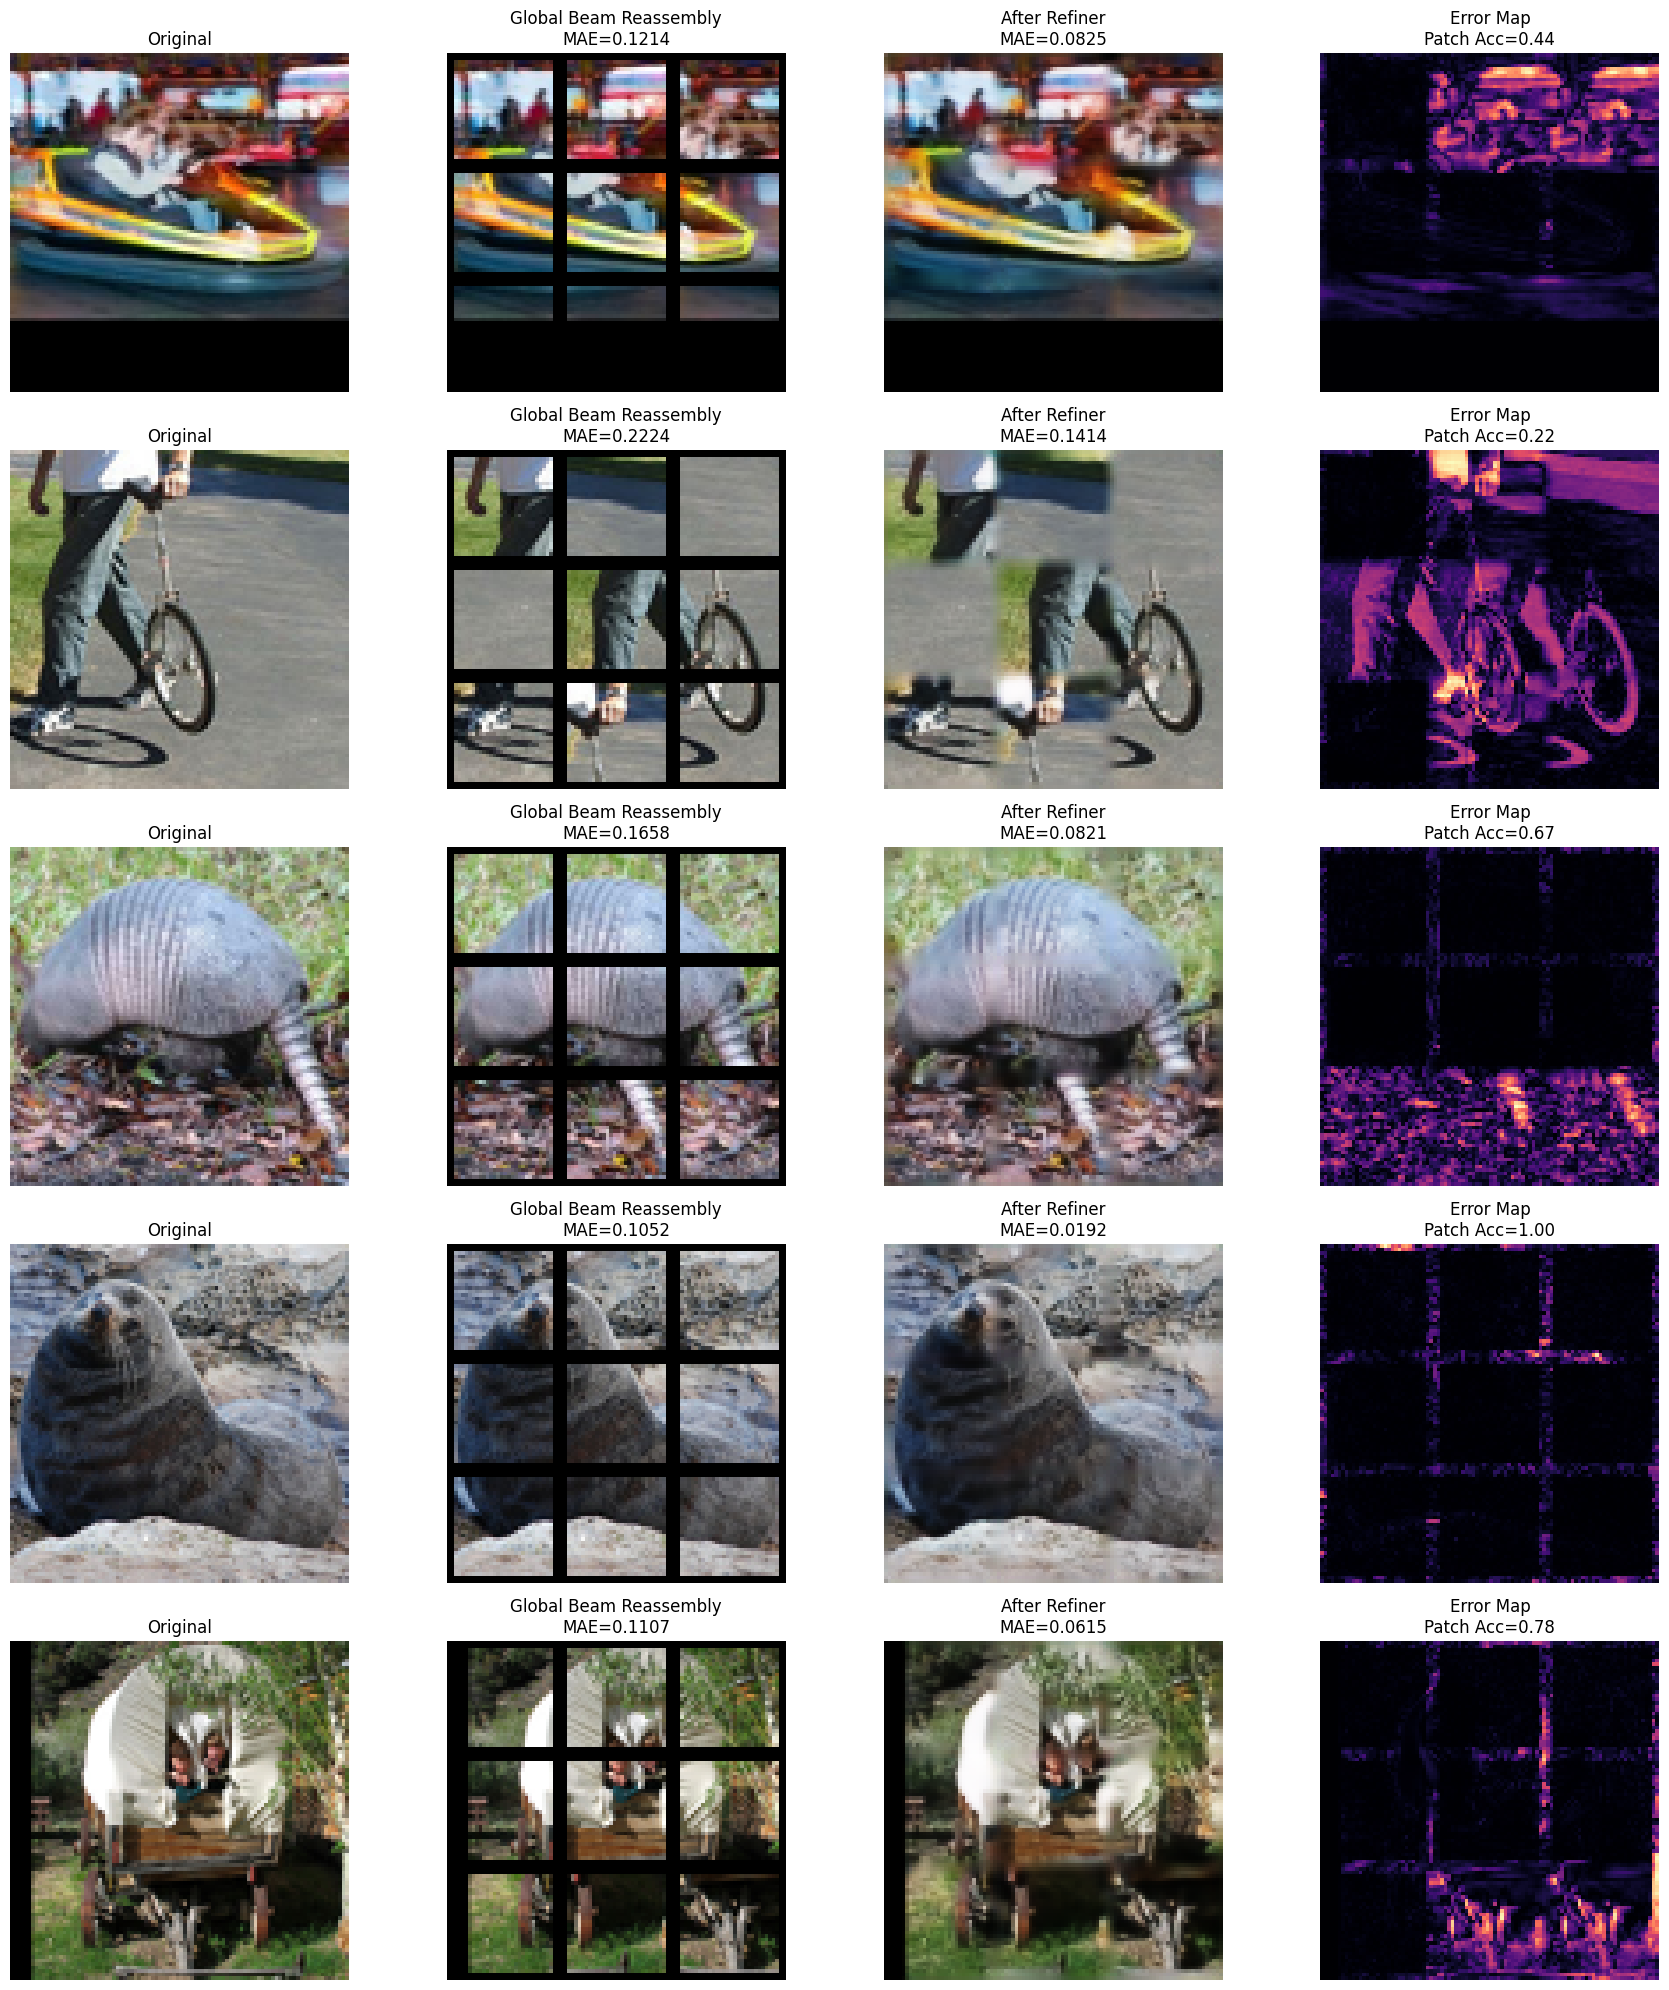

In [ ]:
# ============================================================
# MODEL 4: NEIGHBOR GLOBAL DECODING + BORDER COMPLETION REFINER
# ============================================================

# Keep trained position model
position_model = model


# ============================================================
# CREATE 96x96 CANVAS FROM POSITIONS
# ============================================================

def reconstruct_96_canvas_from_positions(
    patches,
    positions,
    patch_size=32,
    crop_size=28
):
    canvas = np.zeros((96, 96, 3), dtype=np.float32)
    margin = (patch_size - crop_size) // 2

    for patch_idx in range(9):

        pos = positions[patch_idx]
        row = pos // 3
        col = pos % 3

        y = row * patch_size + margin
        x = col * patch_size + margin

        canvas[
            y:y + crop_size,
            x:x + crop_size,
            :
        ] = patches[patch_idx]

    return canvas


# ============================================================
# ORACLE BORDER COMPLETION GENERATOR
# Trains refiner to fill erosion gaps assuming correct order
# ============================================================

def create_oracle_eroded_canvas(
    image,
    patch_size=32,
    crop_size=28
):
    image = image.astype("float32") / 255.0

    canvas = np.zeros((96, 96, 3), dtype=np.float32)
    margin = (patch_size - crop_size) // 2

    for r in range(3):
        for c in range(3):

            y = r * patch_size
            x = c * patch_size

            patch = image[
                y + margin:y + margin + crop_size,
                x + margin:x + margin + crop_size,
                :
            ]

            canvas[
                y + margin:y + margin + crop_size,
                x + margin:x + margin + crop_size,
                :
            ] = patch

    return canvas


class BorderCompletionGenerator(keras.utils.PyDataset):

    def __init__(
        self,
        images,
        batch_size=32,
        shuffle=True,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.images = images
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(images))

        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, idx):

        batch_idx = self.indices[
            idx * self.batch_size:(idx + 1) * self.batch_size
        ]

        bs = len(batch_idx)

        X = np.zeros((bs, 96, 96, 3), dtype=np.float32)
        Y = np.zeros((bs, 96, 96, 3), dtype=np.float32)

        for i, img_idx in enumerate(batch_idx):

            original = self.images[img_idx].astype("float32") / 255.0

            X[i] = create_oracle_eroded_canvas(
                self.images[img_idx]
            )

            Y[i] = original

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


# ============================================================
# REFINER MODEL
# ============================================================

def build_border_completion_refiner():

    inputs = keras.Input(
        shape=(96, 96, 3),
        name="eroded_reassembled_image"
    )

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    skip1 = x

    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    skip2 = x

    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D()(x)
    x = layers.Concatenate()([x, skip2])

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D()(x)
    x = layers.Concatenate()([x, skip1])

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)

    outputs = layers.Conv2D(
        3,
        3,
        padding="same",
        activation="sigmoid",
        name="refined_image"
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="border_completion_refiner"
    )


# ============================================================
# TRAIN REFINER
# ============================================================

refiner_train_generator = BorderCompletionGenerator(
    train_images,
    batch_size=32,
    shuffle=True
)

refiner_val_generator = BorderCompletionGenerator(
    val_images,
    batch_size=32,
    shuffle=False
)

refiner_test_generator = BorderCompletionGenerator(
    test_images,
    batch_size=32,
    shuffle=False
)

refiner_model = build_border_completion_refiner()

refiner_model.summary()

refiner_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mae",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

refiner_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=5,
        restore_best_weights=True,
        mode="min"
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        mode="min"
    ),

    keras.callbacks.ModelCheckpoint(
        "best_neighbor_global_refiner.weights.h5",
        monitor="val_mae",
        save_best_only=True,
        save_weights_only=True,
        mode="min"
    )
]

refiner_history = refiner_model.fit(
    refiner_train_generator,
    validation_data=refiner_val_generator,
    epochs=25,
    callbacks=refiner_callbacks
)

oracle_results = refiner_model.evaluate(
    refiner_test_generator,
    verbose=1
)

print("Oracle-order refiner MAE:", oracle_results[1])


# ============================================================
# EVALUATE FULL PIPELINE:
# NEIGHBOR MODEL + GLOBAL BEAM + REFINER
# ============================================================

def evaluate_neighbor_global_refiner_pipeline(
    position_model,
    refiner_model,
    test_images,
    batch_size=16,
    beam_width=200,
    alpha=0.8,
    beta=0.8
):

    generator = PatchPermutationGenerator(
        test_images,
        batch_size=batch_size,
        repeat_factor=1,
        shuffle=False,
        use_augmentation=False
    )

    maes_before = []
    maes_after = []
    position_accs = []
    full_puzzle_accs = []

    for batch_idx in range(len(generator)):

        x_batch, y_batch = generator[batch_idx]

        position_pred, right_pred, bottom_pred = predict_model_outputs(
            position_model,
            x_batch,
            verbose=0
        )

        true_positions = np.argmax(
            y_batch["sinkhorn_permutation"],
            axis=-1
        )

        global_positions = batch_global_beam_search(
            position_pred,
            right_pred,
            bottom_pred,
            beam_width=beam_width,
            alpha=alpha,
            beta=beta
        )

        position_accs.append(
            np.mean(true_positions == global_positions)
        )

        full_puzzle_accs.append(
            np.mean(
                np.all(
                    true_positions == global_positions,
                    axis=1
                )
            )
        )

        reassembled_batch = []

        for i in range(x_batch.shape[0]):

            canvas = reconstruct_96_canvas_from_positions(
                x_batch[i],
                global_positions[i]
            )

            reassembled_batch.append(canvas)

        reassembled_batch = np.array(
            reassembled_batch,
            dtype=np.float32
        )

        refined_batch = refiner_model.predict(
            reassembled_batch,
            verbose=0
        )

        if isinstance(refined_batch, dict):
            refined_batch = list(refined_batch.values())[0]

        for i in range(x_batch.shape[0]):

            global_idx = batch_idx * batch_size + i

            if global_idx >= len(test_images):
                continue

            original = test_images[global_idx].astype("float32") / 255.0

            mae_before = np.mean(
                np.abs(original - reassembled_batch[i])
            )

            mae_after = np.mean(
                np.abs(original - refined_batch[i])
            )

            maes_before.append(mae_before)
            maes_after.append(mae_after)

    return {
        "position_accuracy": float(np.mean(position_accs)),
        "full_puzzle_accuracy": float(np.mean(full_puzzle_accs)),
        "mae_before_refiner": float(np.mean(maes_before)),
        "std_before_refiner": float(np.std(maes_before)),
        "mae_after_refiner": float(np.mean(maes_after)),
        "std_after_refiner": float(np.std(maes_after)),
    }


model4_results = evaluate_neighbor_global_refiner_pipeline(
    position_model=position_model,
    refiner_model=refiner_model,
    test_images=test_images,
    batch_size=16,
    beam_width=200,
    alpha=0.8,
    beta=0.8
)

print("\n===== MODEL 4: NEIGHBOR GLOBAL + REFINER RESULTS =====")
print(model4_results)

print(
    f"Final Model 4 MAE: {model4_results['mae_after_refiner']:.4f}"
)


# ============================================================
# VISUALIZE FINAL MODEL 4
# ============================================================

def visualize_neighbor_global_refiner_pipeline(
    position_model,
    refiner_model,
    test_images,
    num_examples=5,
    batch_size=16,
    beam_width=200,
    alpha=0.8,
    beta=0.8
):

    generator = PatchPermutationGenerator(
        test_images,
        batch_size=batch_size,
        repeat_factor=1,
        shuffle=False,
        use_augmentation=False
    )

    x_batch, y_batch = generator[0]

    position_pred, right_pred, bottom_pred = predict_model_outputs(
        position_model,
        x_batch,
        verbose=0
    )

    true_positions = np.argmax(
        y_batch["sinkhorn_permutation"],
        axis=-1
    )

    global_positions = batch_global_beam_search(
        position_pred,
        right_pred,
        bottom_pred,
        beam_width=beam_width,
        alpha=alpha,
        beta=beta
    )

    reassembled = []

    for i in range(x_batch.shape[0]):

        canvas = reconstruct_96_canvas_from_positions(
            x_batch[i],
            global_positions[i]
        )

        reassembled.append(canvas)

    reassembled = np.array(
        reassembled,
        dtype=np.float32
    )

    refined = refiner_model.predict(
        reassembled,
        verbose=0
    )

    if isinstance(refined, dict):
        refined = list(refined.values())[0]

    num_examples = min(
        num_examples,
        x_batch.shape[0]
    )

    plt.figure(figsize=(18, 4 * num_examples))

    for i in range(num_examples):

        original = test_images[i].astype("float32") / 255.0

        mae_before = np.mean(
            np.abs(original - reassembled[i])
        )

        mae_after = np.mean(
            np.abs(original - refined[i])
        )

        pos_acc = np.mean(
            true_positions[i] == global_positions[i]
        )

        error_map = np.mean(
            np.abs(original - refined[i]),
            axis=-1
        )

        plt.subplot(num_examples, 4, 4 * i + 1)
        plt.imshow(original)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(num_examples, 4, 4 * i + 2)
        plt.imshow(reassembled[i])
        plt.title(
            f"Global Beam Reassembly\nMAE={mae_before:.4f}"
        )
        plt.axis("off")

        plt.subplot(num_examples, 4, 4 * i + 3)
        plt.imshow(refined[i])
        plt.title(
            f"After Refiner\nMAE={mae_after:.4f}"
        )
        plt.axis("off")

        plt.subplot(num_examples, 4, 4 * i + 4)
        plt.imshow(error_map, cmap="magma")
        plt.title(
            f"Error Map\nPatch Acc={pos_acc:.2f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_neighbor_global_refiner_pipeline(
    position_model=position_model,
    refiner_model=refiner_model,
    test_images=test_images,
    num_examples=5,
    batch_size=16,
    beam_width=200,
    alpha=0.8,
    beta=0.8
)